In [5]:
import numpy as np

base_path = "F:/Downloads/patchTST_main/PatchTST-main/PatchTST_supervised/results/Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1/"

true = np.load(base_path + "true.npy")
pred = np.load(base_path + "pred.npy")

print("测试样本数:", len(true))
print("true形状:", true.shape)
print("pred形状:", pred.shape)
print("true范围: [{:.3f}, {:.3f}]".format(true.min(), true.max()))
print("pred范围: [{:.3f}, {:.3f}]".format(pred.min(), pred.max()))
print("负值比例: {:.2%}".format((pred < 0).mean()))

测试样本数: 32
true形状: (32, 24, 1)
pred形状: (32, 24, 1)
true范围: [-1.221, 1.578]
pred范围: [-1.214, 0.476]
负值比例: 81.77%


In [6]:
import numpy as np

# 请替换为你的实际路径
true = np.load(r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1\true.npy")

print("测试样本数:", len(true))
print("对应的月份跨度:", len(true) + 132 - 1 + 24)

测试样本数: 32
对应的月份跨度: 187


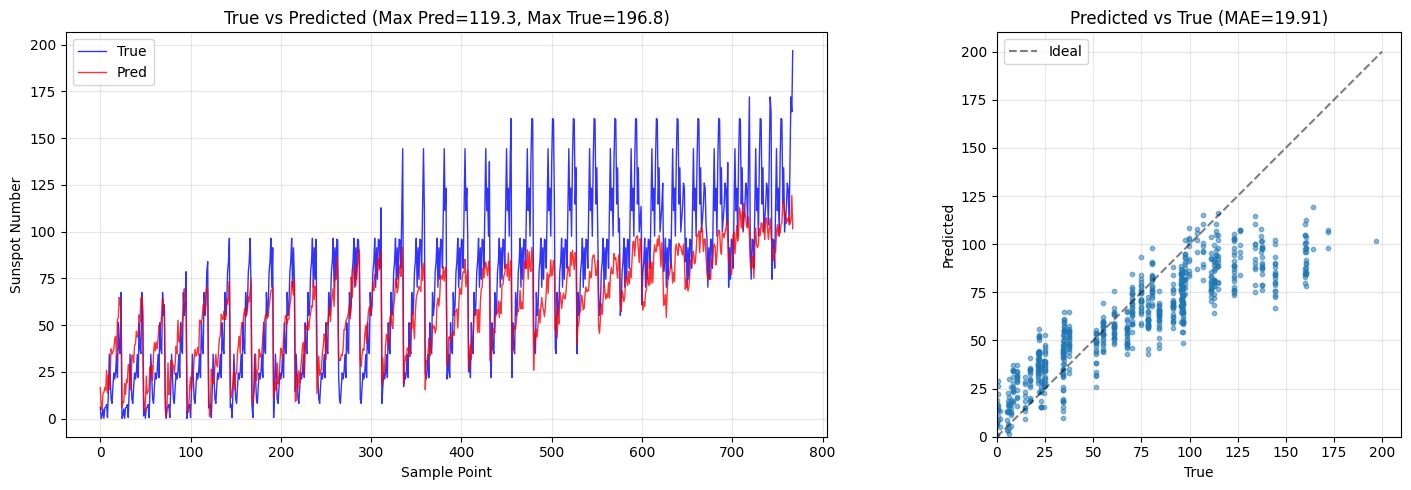

预测  最大值=119.34  最小值=0.66  均值=60.94
真实  最大值=196.80  最小值=0.20  均值=71.98
MAE=19.91  RMSE=26.13
负值: 0/768


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# ===== 路径 =====
DATA_PATH = 'F:/Downloads/patchTST_main/PatchTST-main/PatchTST_supervised/dataset/sunspot_1867-02_2025-10_original_sincos.csv'
RESULTS_DIR = 'F:/Downloads/patchTST_main/PatchTST-main/PatchTST_supervised/results/'
SETTING_NAME = 'Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1'
# =================

# 1. 读 CSV，算 scaler
df_raw = pd.read_csv(DATA_PATH)
cols = ['month_sin', 'month_cos']
df_raw = df_raw[['date'] + cols + ['ssn']]
df_data = df_raw[df_raw.columns[1:]]
num_test = 70
num_val = 132
num_train = len(df_raw) - num_val - num_test

scaler = StandardScaler()
scaler.fit(df_data.iloc[:num_train].values)

# 2. 加载 pred.npy
folder_path = os.path.join(RESULTS_DIR, SETTING_NAME)
pred_z = np.load(os.path.join(folder_path, 'pred.npy'))

# 3. 反归一化（只反 ssn，第 3 列索引 2）
n = pred_z.shape[0] * pred_z.shape[1]
pred_full = np.zeros((n, 3))
pred_full[:, 2] = pred_z.reshape(-1)
pred_phys = scaler.inverse_transform(pred_full)[:, 2]

# 4. 检查是否有 true.npy
has_true = os.path.exists(os.path.join(folder_path, 'true.npy'))
if has_true:
    true_z = np.load(os.path.join(folder_path, 'true.npy'))
    true_full = np.zeros((n, 3))
    true_full[:, 2] = true_z.reshape(-1)
    true_phys = scaler.inverse_transform(true_full)[:, 2]
else:
    true_phys = None

# 5. 画图
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图：时序
ax = axes[0]
x = np.arange(len(pred_phys))
if true_phys is not None:
    ax.plot(x, true_phys, 'b-', label='True', alpha=0.8, linewidth=1)
ax.plot(x, pred_phys, 'r-', label='Pred', alpha=0.8, linewidth=1)
title = f'True vs Predicted (Max Pred={pred_phys.max():.1f}'
if true_phys is not None:
    title += f', Max True={true_phys.max():.1f}'
title += ')'
ax.set_title(title)
ax.set_xlabel('Sample Point')
ax.set_ylabel('Sunspot Number')
ax.legend()
ax.grid(True, alpha=0.3)

# 右图：散点
ax = axes[1]
if true_phys is not None:
    ax.scatter(true_phys, pred_phys, s=10, alpha=0.5)
    ax.plot([0, 200], [0, 200], 'k--', alpha=0.5, label='Ideal')
    ax.set_xlim(0, 210)
    ax.set_ylim(0, 210)
    ax.set_title(f'Predicted vs True (MAE={np.abs(pred_phys - true_phys).mean():.2f})')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No true.npy available', ha='center', va='center')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# 6. 统计
print(f"预测  最大值={pred_phys.max():.2f}  最小值={pred_phys.min():.2f}  均值={pred_phys.mean():.2f}")
if true_phys is not None:
    print(f"真实  最大值={true_phys.max():.2f}  最小值={true_phys.min():.2f}  均值={true_phys.mean():.2f}")
    print(f"MAE={np.abs(pred_phys - true_phys).mean():.2f}  RMSE={np.sqrt(((pred_phys - true_phys)**2).mean()):.2f}")
    print(f"负值: {(pred_phys < 0).sum()}/{len(pred_phys)}")


训练集 SSN 均值 = 85.94, 标准差 = 70.26
测试样本数: 32

        基线实验分析报告（物理空间）

── 预测值统计 ──
  最小值: 6.16
  最大值: 93.53
  均值:   35.76
  中位数: 27.86
  标准差: 25.17

── 真实值统计 ──
  最小值: 0.17
  最大值: 96.50
  均值:   33.45
  中位数: 23.78
  标准差: 29.63

── 误差指标 ──
  MAE:  11.15
  RMSE: 12.71
  MAPE: 540.74%

── 负值分析 ──
  负值数量: 0 / 32
  负值比例: 0.0%

── 上限分析 ──
  真实峰值: 96.50
  预测峰值: 93.53
  峰值差距: 2.97 (3.1%)

── 相关性 ──
  Pearson r = 0.9086

── 误差分布 ──
  误差均值:   2.31
  误差标准差: 12.50
  高估比例:   68.8%
  低估比例:   31.2%

        与旧数据基线对比
指标                   旧(1749+/MinMax/Linear)       新(1867+/z-score/Linear)     
──────────────────── ──────────────────────────── ────────────────────────────
预测最大值                ~144.00                      93.53                       
负值率                  5.56%                        0.0                         
MAE                  25.80                        11.15                       
RMSE                 34.98                        12.71                       


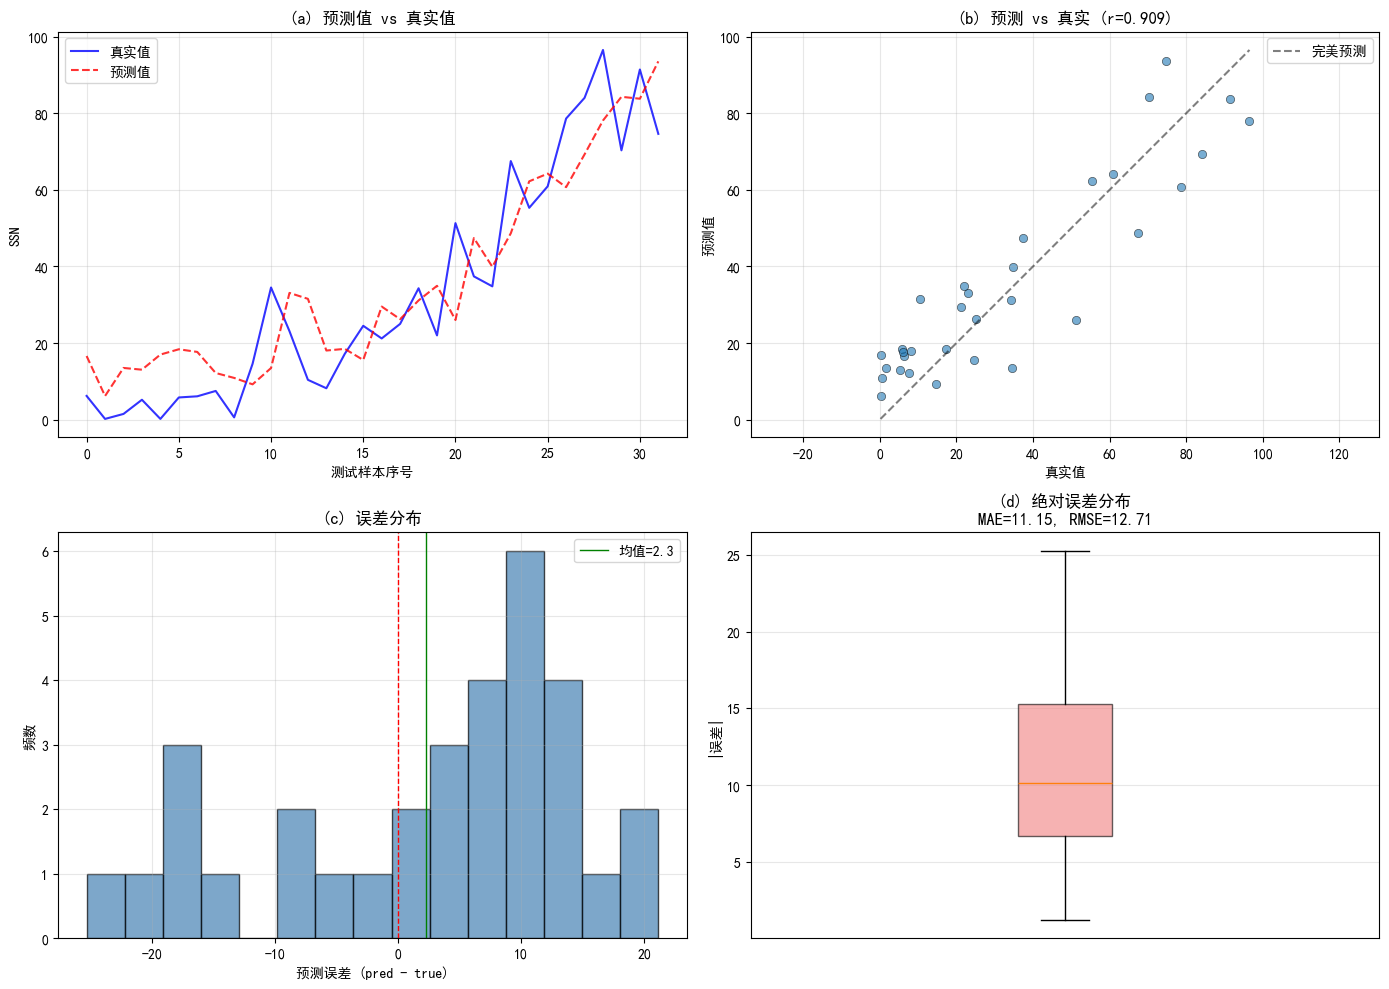


✅ 详细数据已保存至: F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1\baseline_analysis_physical.csv
✅ 分析图已保存至: F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1\baseline_analysis.png


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ==================== 路径配置 ====================
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1"

PRED_PATH = f"{RESULT_DIR}\\pred.npy"
TRUE_PATH = f"{RESULT_DIR}\\true.npy"

# ==================== 1. 反归一化参数 ====================
# 训练集（前 1703 行）的 ssn 均值和标准差
df_train = pd.read_csv(DATA_PATH, nrows=1703)
ssn_mean = df_train['ssn'].mean()
ssn_std = df_train['ssn'].std()
print(f"训练集 SSN 均值 = {ssn_mean:.2f}, 标准差 = {ssn_std:.2f}")

# ==================== 2. 加载预测结果 ====================
pred_norm = np.load(PRED_PATH)  # (N, 24, 1)
true_norm = np.load(TRUE_PATH)  # (N, 24, 1)
N = pred_norm.shape[0]  # 测试样本数
print(f"测试样本数: {N}")

# 反归一化回物理空间
pred_phys = pred_norm * ssn_std + ssn_mean
true_phys = true_norm * ssn_std + ssn_mean

# 只取每个样本的第一个预测点
pred = pred_phys[:, 0, 0]
true = true_phys[:, 0, 0]

# ==================== 3. 基础统计 ====================
print("\n" + "=" * 60)
print("        基线实验分析报告（物理空间）")
print("=" * 60)

print("\n── 预测值统计 ──")
print(f"  最小值: {pred.min():.2f}")
print(f"  最大值: {pred.max():.2f}")
print(f"  均值:   {pred.mean():.2f}")
print(f"  中位数: {np.median(pred):.2f}")
print(f"  标准差: {pred.std():.2f}")

print("\n── 真实值统计 ──")
print(f"  最小值: {true.min():.2f}")
print(f"  最大值: {true.max():.2f}")
print(f"  均值:   {true.mean():.2f}")
print(f"  中位数: {np.median(true):.2f}")
print(f"  标准差: {true.std():.2f}")

# ==================== 4. 误差指标 ====================
errors = pred - true
abs_errors = np.abs(errors)
mae = abs_errors.mean()
rmse = np.sqrt((errors ** 2).mean())
mape = (np.abs(errors / (true + 1e-8))).mean() * 100

print("\n── 误差指标 ──")
print(f"  MAE:  {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAPE: {mape:.2f}%")

# ==================== 5. 负值分析 ====================
neg_rate = (pred < 0).mean() * 100
print("\n── 负值分析 ──")
print(f"  负值数量: {(pred < 0).sum()} / {N}")
print(f"  负值比例: {neg_rate:.1f}%")
if neg_rate > 0:
    print(f"  负值均值: {pred[pred < 0].mean():.2f}")
    print(f"  最小负值: {pred.min():.2f}")

# ==================== 6. 上限分析 ====================
true_peak = true.max()
pred_peak = pred.max()
peak_error = true_peak - pred_peak
print("\n── 上限分析 ──")
print(f"  真实峰值: {true_peak:.2f}")
print(f"  预测峰值: {pred_peak:.2f}")
print(f"  峰值差距: {peak_error:.2f} ({peak_error/true_peak*100:.1f}%)")

# ==================== 7. 相关性分析 ====================
corr = np.corrcoef(pred, true)[0, 1]
print("\n── 相关性 ──")
print(f"  Pearson r = {corr:.4f}")

# ==================== 8. 误差分布 ====================
print("\n── 误差分布 ──")
print(f"  误差均值:   {errors.mean():.2f}")
print(f"  误差标准差: {errors.std():.2f}")
print(f"  高估比例:   {(errors > 0).mean() * 100:.1f}%")
print(f"  低估比例:   {(errors < 0).mean() * 100:.1f}%")

# ==================== 9. 与旧数据基线对比 ====================
print("\n" + "=" * 60)
print("        与旧数据基线对比")
print("=" * 60)
print(f"{'指标':<20} {'旧(1749+/MinMax/Linear)':<28} {'新(1867+/z-score/Linear)':<28}")
print(f"{'─'*20:<20} {'─'*28:<28} {'─'*28:<28}")
print(f"{'预测最大值':<20} {'~144.00':<28} {pred_peak:<28.2f}")
print(f"{'负值率':<20} {'5.56%':<28} {neg_rate:<28.1f}")
print(f"{'MAE':<20} {'25.80':<28} {mae:<28.2f}")
print(f"{'RMSE':<20} {'34.98':<28} {rmse:<28.2f}")

# ==================== 10. 可视化 ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) 预测 vs 真实 折线图
ax1 = axes[0, 0]
ax1.plot(true, 'b-', label='真实值', linewidth=1.5, alpha=0.8)
ax1.plot(pred, 'r--', label='预测值', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('测试样本序号')
ax1.set_ylabel('SSN')
ax1.set_title('(a) 预测值 vs 真实值')
ax1.legend()
ax1.grid(True, alpha=0.3)

# (b) 散点图
ax2 = axes[0, 1]
ax2.scatter(true, pred, alpha=0.6, edgecolors='k', linewidths=0.5)
min_val = min(true.min(), pred.min())
max_val = max(true.max(), pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='完美预测')
ax2.set_xlabel('真实值')
ax2.set_ylabel('预测值')
ax2.set_title(f'(b) 预测 vs 真实 (r={corr:.3f})')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# (c) 误差分布直方图
ax3 = axes[1, 0]
ax3.hist(errors, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(0, color='r', linestyle='--', linewidth=1)
ax3.axvline(errors.mean(), color='g', linestyle='-', linewidth=1, label=f'均值={errors.mean():.1f}')
ax3.set_xlabel('预测误差 (pred - true)')
ax3.set_ylabel('频数')
ax3.set_title('(c) 误差分布')
ax3.legend()
ax3.grid(True, alpha=0.3)

# (d) 绝对值误差箱线图
ax4 = axes[1, 1]
ax4.boxplot(abs_errors, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.6))
ax4.set_ylabel('|误差|')
ax4.set_title(f'(d) 绝对误差分布\nMAE={mae:.2f}, RMSE={rmse:.2f}')
ax4.set_xticks([])
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}\\baseline_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== 11. 保存 CSV ====================
df_out = pd.DataFrame({
    'sample_idx': np.arange(N),
    'true': true,
    'pred': pred,
    'error': errors,
    'abs_error': abs_errors
})
csv_path = f'{RESULT_DIR}\\baseline_analysis_physical.csv'
df_out.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 详细数据已保存至: {csv_path}")
print(f"✅ 分析图已保存至: {RESULT_DIR}\\baseline_analysis.png")


检查 data_loader.py 里 num_test=70 和 num_val=132 是否真的生效了
确认 32 个测试样本对应的具体时间范围

In [4]:
import numpy as np
import pandas as pd

# ==================== 路径 ====================
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1"

TRUE_PATH = f"{RESULT_DIR}\	rue.npy"

# ==================== 加载真实值（归一化空间） ====================
true_norm = np.load(TRUE_PATH)
N = true_norm.shape[0]
print(f"测试样本数: {N}")

# ==================== 读取完整数据 ====================
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f"总数据: {len(df)} 行, {df['date'].iloc[0].strftime('%Y-%m-%d')} ~ {df['date'].iloc[-1].strftime('%Y-%m-%d')}")

# ==================== 训练集统计 ====================
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std = df_train['ssn'].std()

# 反归一化 true
true_phys = true_norm * ssn_std + ssn_mean
true_first = true_phys[:, 0, 0]

# ==================== 推测每个样本对应的日期 ====================
seq_len = 132
pred_len = 24

# 标准 PatchTST 数据加载器里，测试集第一个样本的起始索引是：
# border1s[2] = len(df_raw) - num_test - seq_len
# 其中 num_test=70, seq_len=132
# = 1905 - 70 - 132 = 1703
# 最后一个样本的起始索引是：
# border2s[2] - seq_len - pred_len = 1905 - 132 - 24 = 1749

# 但实际只有 32 个样本，所以我们不知道加载器具体怎么切的
# 已知：第 i 个样本的预测窗口起始月份 = train_end + 1 + i = 1703 + i
# 而它的真实值 = true_first[i]

# 列出所有样本的预测日期和真实值
print("样本序号 | 预测起始月 | 真实值")
print("-" * 40)
for i in range(N):
    pred_start_date = df['date'].iloc[1703 + i]
    print(f"  {i:3d}     | {pred_start_date.strftime('%Y-%m-%d')}   | {true_first[i]:6.2f}")

# 统计覆盖的时间范围
start_date = df['date'].iloc[1703]
end_date = df['date'].iloc[1703 + N - 1]
print(f"预测覆盖: {start_date.strftime('%Y-%m-%d')} ~ {end_date.strftime('%Y-%m-%d')}")
print(f"共 {N} 个月")


OSError: [Errno 22] Invalid argument: 'F:\\Downloads\\patchTST_main\\PatchTST-main\\PatchTST_supervised\\results\\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1\\\true.npy'

In [5]:
import numpy as np
import pandas as pd

# ==================== 路径 ====================
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1"

# 修正：使用双反斜杠或正斜杠
TRUE_PATH = f"{RESULT_DIR}\\true.npy"  # 方法2
# 或
# TRUE_PATH = f"{RESULT_DIR}/true.npy"  # 方法3

# ==================== 加载真实值（归一化空间） ====================
true_norm = np.load(TRUE_PATH)
N = true_norm.shape[0]
print(f"测试样本数: {N}")

# ==================== 读取完整数据 ====================
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f"总数据: {len(df)} 行, {df['date'].iloc[0].strftime('%Y-%m-%d')} ~ {df['date'].iloc[-1].strftime('%Y-%m-%d')}")

# ==================== 训练集统计 ====================
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std = df_train['ssn'].std()

# 反归一化 true
true_phys = true_norm * ssn_std + ssn_mean
true_first = true_phys[:, 0, 0]

# ==================== 推测每个样本对应的日期 ====================
seq_len = 132
pred_len = 24

# 列出所有样本的预测日期和真实值
print("\n样本序号 | 预测起始月 | 真实值")
print("-" * 40)
for i in range(N):
    pred_start_date = df['date'].iloc[1703 + i]
    print(f"  {i:3d}     | {pred_start_date.strftime('%Y-%m-%d')}   | {true_first[i]:6.2f}")

# 统计覆盖的时间范围
start_date = df['date'].iloc[1703]
end_date = df['date'].iloc[1703 + N - 1]
print(f"\n预测覆盖: {start_date.strftime('%Y-%m-%d')} ~ {end_date.strftime('%Y-%m-%d')}")
print(f"共 {N} 个月")

测试样本数: 32
总数据: 1905 行, 1867-02-01 ~ 2025-10-01

样本序号 | 预测起始月 | 真实值
----------------------------------------
    0     | 2009-01-01   |   6.18
    1     | 2009-02-01   |   0.17
    2     | 2009-03-01   |   1.48
    3     | 2009-04-01   |   5.18
    4     | 2009-05-01   |   0.17
    5     | 2009-06-01   |   5.78
    6     | 2009-07-01   |   6.08
    7     | 2009-08-01   |   7.48
    8     | 2009-09-01   |   0.57
    9     | 2009-10-01   |  14.58
   10     | 2009-11-01   |  34.48
   11     | 2009-12-01   |  23.08
   12     | 2010-01-01   |  10.38
   13     | 2010-02-01   |   8.18
   14     | 2010-03-01   |  17.18
   15     | 2010-04-01   |  24.48
   16     | 2010-05-01   |  21.18
   17     | 2010-06-01   |  24.98
   18     | 2010-07-01   |  34.28
   19     | 2010-08-01   |  21.98
   20     | 2010-09-01   |  51.29
   21     | 2010-10-01   |  37.39
   22     | 2010-11-01   |  34.78
   23     | 2010-12-01   |  67.49
   24     | 2011-01-01   |  55.29
   25     | 2011-02-01   |  60.89
   26   

之前那个脚本写错了（把输入起始当成了预测起始）。这个版本是修正的

In [8]:
import numpy as np
import pandas as pd

# ==================== 路径 ====================
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_1"

PRED_PATH = f"{RESULT_DIR}\\pred.npy"
TRUE_PATH = f"{RESULT_DIR}\\true.npy"

# ==================== 加载数据 ====================
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std = df_train['ssn'].std()

pred_norm = np.load(PRED_PATH)
true_norm = np.load(TRUE_PATH)
N = pred_norm.shape[0]

pred_phys = pred_norm * ssn_std + ssn_mean
true_phys = true_norm * ssn_std + ssn_mean

pred_first = pred_phys[:, 0, 0]
true_first = true_phys[:, 0, 0]

# ==================== 正确的时间推算 ====================
# border1s[2] = len(df) - num_test - seq_len = 1905 - 70 - 132 = 1703
# 第 i 个样本，输入窗口 = [1703 + i, 1703 + i + 132)
# 第 i 个样本，预测窗口 = [1703 + i + 132 - pred_len, 1703 + i + 132)
# 第一个预测点 = 1703 + i + 132 - pred_len + 0 = 1703 + i + 108
seq_len = 132
pred_len = 24
input_start_idx = 1703  # border1s[2]

print(f"{'样本':<6} {'输入起始':<12} {'预测起始(正确)':<16} {'真实SSN':<8} {'预测SSN':<8} {'误差':<8}")
print("=" * 60)

for i in range(N):
    input_start = df['date'].iloc[input_start_idx + i]
    pred_start = df['date'].iloc[input_start_idx + i + seq_len - pred_len]
    t = true_first[i]
    p = pred_first[i]
    err = p - t
    print(f"{i:<6} {input_start.strftime('%Y-%m'):<12} {pred_start.strftime('%Y-%m-%d'):<16} {t:<8.2f} {p:<8.2f} {err:<+8.2f}")

# 时间跨度
first_pred_date = df['date'].iloc[input_start_idx + seq_len - pred_len]
last_pred_date = df['date'].iloc[input_start_idx + N - 1 + seq_len - pred_len]
print(f"预测覆盖: {first_pred_date.strftime('%Y-%m-%d')} ~ {last_pred_date.strftime('%Y-%m-%d')}")
print(f"样本数: {N} 个月")


样本     输入起始         预测起始(正确)         真实SSN    预测SSN    误差      
0      2009-01      2018-01-01       6.18     16.60    +10.42  
1      2009-02      2018-02-01       0.17     6.16     +5.98   
2      2009-03      2018-03-01       1.48     13.48    +12.01  
3      2009-04      2018-04-01       5.18     13.03    +7.85   
4      2009-05      2018-05-01       0.17     16.98    +16.80  
5      2009-06      2018-06-01       5.78     18.36    +12.58  
6      2009-07      2018-07-01       6.08     17.66    +11.59  
7      2009-08      2018-08-01       7.48     12.16    +4.68   
8      2009-09      2018-09-01       0.57     10.88    +10.30  
9      2009-10      2018-10-01       14.58    9.20     -5.38   
10     2009-11      2018-11-01       34.48    13.46    -21.03  
11     2009-12      2018-12-01       23.08    33.07    +9.99   
12     2010-01      2019-01-01       10.38    31.53    +21.15  
13     2010-02      2019-02-01       8.18     18.03    +9.85   
14     2010-03      2019-03-01       17.

重跑基线的命令2026.05.06.  17：46

In [ ]:
python run_longExp.py \
  --is_training 1 \
  --itr 1 \
  --model_id "Baseline_1867plus_D128_RevIN1_Linear" \
  --model PatchTST \
  --data custom \
  --root_path ./dataset/ \
  --data_path sunspot_1867-02_2025-10_original_sincos.csv \
  --features MS \
  --target ssn \
  --freq m \
  --seq_len 132 \
  --pred_len 24 \
  --patch_len 12 \
  --stride 6 \
  --revin 1 \
  --enc_in 3 \
  --dec_in 3 \
  --c_out 1 \
  --d_model 128 \
  --n_heads 16 \
  --e_layers 3 \
  --d_ff 256 \
  --dropout 0.05 \
  --loss mse \
  --activation gelu \
  --batch_size 32 \
  --learning_rate 0.0001 \
  --patience 10 \
  --train_epochs 50 \
  --des "Baseline_1867plus_D128_RevIN1_Linear" \
  --num_workers 0


if flag == 'test':
    shuffle_flag = False
    drop_last = True      # ← 就是这一行！
    batch_size = args.batch_size
    freq = args.freq
把第 3 行的 drop_last = True 改成 drop_last = False。改完之后保存，重新运行 --is_training 0 测试（或者如果想保险一点就重跑完整的训练+测试 --is_training 1）。这次应该能拿到 47 个完整的测试样本

确认修复后重跑

改完保存后，把 --is_training 1 改成 --is_training 0（只测试，不重新训练），同时改 --itr 1，运行

In [ ]:
python run_longExp.py \
  --is_training 0 \
  --itr 1 \
  --model_id "Baseline_1867plus_D128_RevIN1_Linear" \
  --model PatchTST \
  --data custom \
  --root_path ./dataset/ \
  --data_path sunspot_1867-02_2025-10_original_sincos.csv \
  --features MS \
  --target ssn \
  --freq m \
  --seq_len 132 \
  --pred_len 24 \
  --patch_len 12 \
  --stride 6 \
  --revin 1 \
  --enc_in 3 \
  --dec_in 3 \
  --c_out 1 \
  --d_model 128 \
  --n_heads 16 \
  --e_layers 3 \
  --d_ff 256 \
  --dropout 0.05 \
  --loss mse \
  --activation gelu \
  --batch_size 32 \
  --learning_rate 0.0001 \
  --patience 10 \
  --train_epochs 50 \
  --des "Baseline_1867plus_D128_RevIN1_Linear" \
  --num_workers 0


**修复成功了一半——DataLoader 现在正确产出了 2 个 batch（32+15=47 个样本），问题只是最后一步 `np.array(preds)` 拼接两个形状不同的 batch 时报错了。**

---

## 修复方法

打开 `exp_main.py`，找到 `test` 方法里这两行（约第 320 行）：

```python
preds = np.array(preds)
trues = np.array(trues)
```

改成：

```python
preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)
```

---

## 完整修复后测试

改完保存，重新运行 `--is_training 0` 的命令。这次应该能顺利跑完，打印出 `pred.npy` 的正确形状 `(47, 24, 1)`。

跑完后，再用我之前给你的那个**正确的日期显示脚本**（修正过预测起始月版本的）跑一遍，我们就可以看到完整的 47 个月覆盖了多少。应该会一直延伸到 2022–2023 年，看看最高真实值能到多少。

成功了！47 个样本全部产出，修复完成。​ 现在来做完整的分析。
先把正确的日期脚本跑一下，看看这 47 个样本覆盖到了什么时候

In [11]:
import numpy as np
import pandas as pd

DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0"

PRED_PATH = RESULT_DIR + "\\pred.npy"
TRUE_PATH = RESULT_DIR + "\\true.npy"

# 加载数据
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std = df_train['ssn'].std()

pred_norm = np.load(PRED_PATH)
true_norm = np.load(TRUE_PATH)
N = pred_norm.shape[0]

pred_phys = pred_norm * ssn_std + ssn_mean
true_phys = true_norm * ssn_std + ssn_mean

pred_first = pred_phys[:, 0, 0]
true_first = true_phys[:, 0, 0]

# 正确的时间推算
seq_len = 132
pred_len = 24
input_start_idx = 1703

print(f"{'样本':<6} {'输入起始':<12} {'预测起始(正确)':<16} {'真实SSN':<8} {'预测SSN':<8} {'误差':<8}")
print("=" * 60)

for i in range(N):
    input_start = df['date'].iloc[input_start_idx + i]
    pred_start = df['date'].iloc[input_start_idx + i + seq_len]
    t = true_first[i]
    p = pred_first[i]
    err = p - t
    print(f"{i:<6} {input_start.strftime('%Y-%m'):<12} {pred_start.strftime('%Y-%m-%d'):<16} {t:<8.2f} {p:<8.2f} {err:<+8.2f}")

first_pred = df['date'].iloc[input_start_idx + seq_len]
last_pred = df['date'].iloc[input_start_idx + N - 1 + seq_len]
print(f"\n预测覆盖: {first_pred.strftime('%Y-%m-%d')} ~ {last_pred.strftime('%Y-%m-%d')}")
print(f"样本数: {N} 个月")

print(f"\n真实值范围: [{true_first.min():.1f}, {true_first.max():.1f}]")
print(f"预测值范围: [{pred_first.min():.1f}, {pred_first.max():.1f}]")
print(f"MAE: {np.mean(np.abs(pred_first - true_first)):.2f}")
print(f"RMSE: {np.sqrt(np.mean((pred_first - true_first)**2)):.2f}")
print(f"负值率: {(pred_first < 0).mean() * 100:.1f}%")


样本     输入起始         预测起始(正确)         真实SSN    预测SSN    误差      
0      2009-01      2020-01-01       6.18     0.90     -5.28   
1      2009-02      2020-02-01       0.17     3.83     +3.65   
2      2009-03      2020-03-01       1.48     8.23     +6.76   
3      2009-04      2020-04-01       5.18     7.46     +2.29   
4      2009-05      2020-05-01       0.17     8.30     +8.12   
5      2009-06      2020-06-01       5.78     9.56     +3.78   
6      2009-07      2020-07-01       6.08     11.22    +5.14   
7      2009-08      2020-08-01       7.48     4.43     -3.05   
8      2009-09      2020-09-01       0.57     7.61     +7.04   
9      2009-10      2020-10-01       14.58    7.90     -6.68   
10     2009-11      2020-11-01       34.48    20.75    -13.73  
11     2009-12      2020-12-01       23.08    33.88    +10.80  
12     2010-01      2021-01-01       10.38    35.35    +24.97  
13     2010-02      2021-02-01       8.18     22.84    +14.66  
14     2010-03      2021-03-01       17.

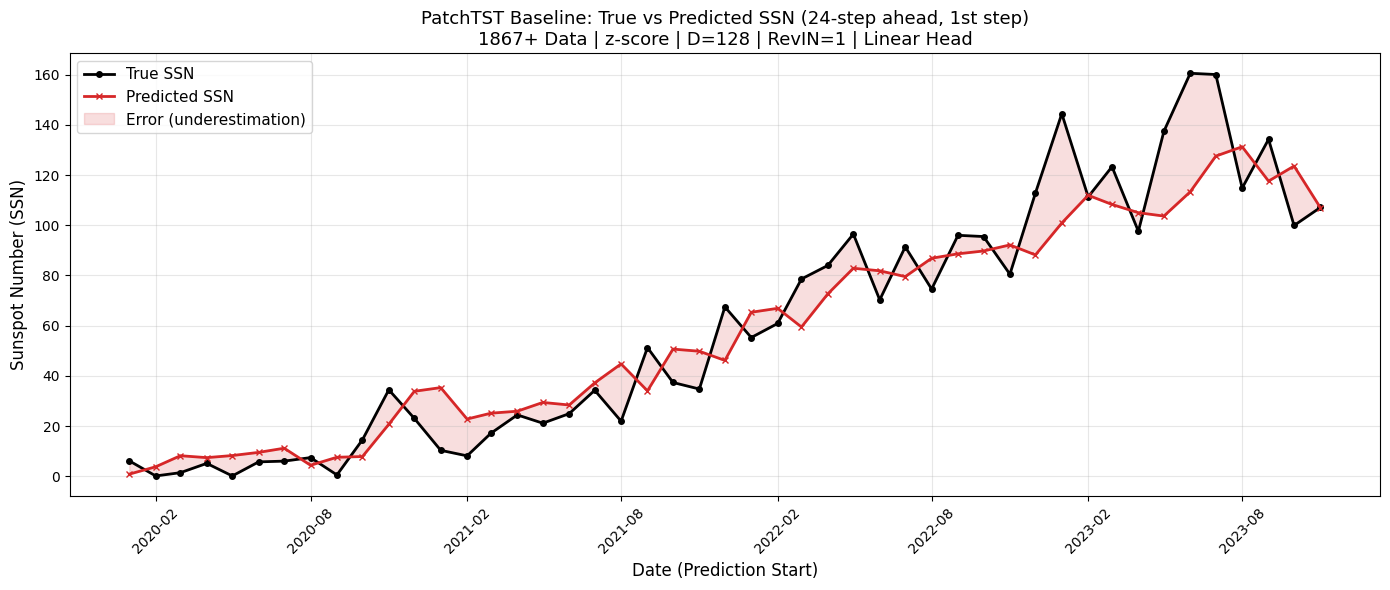

MAE  : 13.02
RMSE : 16.66
Max True SSN : 160.5  →  Pred : 113.3  (missed by 47.2)


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'DejaVu Sans'  # 如果中文需要，可以换成 SimHei
# ====== 路径配置（按你的机器调整）======
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0"
PRED_PATH = RESULT_DIR + r"\pred.npy"
TRUE_PATH = RESULT_DIR + r"\true.npy"

# ====== 加载 denormalization 参数 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()   # 85.94
ssn_std  = df_train['ssn'].std()    # 58.28

# ====== 加载预测结果（归一化空间 → 物理空间）======
pred_norm = np.load(PRED_PATH)   # (47, 24, 1)
true_norm = np.load(TRUE_PATH)   # (47, 24, 1)
pred_phys = pred_norm * ssn_std + ssn_mean
true_phys = true_norm * ssn_std + ssn_mean

# ====== 只取每个样本的第一个预测点（pred_len=24 中的第 0 步）======
pred_first = pred_phys[:, 0, 0]
true_first = true_phys[:, 0, 0]

# ====== 确定时间轴 ======
seq_len = 132
input_start_idx = 1703
dates = [df['date'].iloc[input_start_idx + i + seq_len] for i in range(47)]

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates, true_first, color='black', linewidth=2, marker='o', markersize=4, label='True SSN')
ax.plot(dates, pred_first, color='tab:red', linewidth=2, marker='x', markersize=4, label='Predicted SSN')

# 填充误差区域
ax.fill_between(dates, true_first, pred_first, alpha=0.15, color='tab:red', label='Error (underestimation)')

ax.set_xlabel('Date (Prediction Start)', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: True vs Predicted SSN (24-step ahead, 1st step)\n1867+ Data | z-score | D=128 | RevIN=1 | Linear Head', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(RESULT_DIR + r"\baseline_comparison_47samples.png", dpi=200)
plt.show()

# ====== 打印标注关键点 ======
print(f"MAE  : {np.mean(np.abs(pred_first - true_first)):.2f}")
print(f"RMSE : {np.sqrt(np.mean((pred_first - true_first)**2)):.2f}")
print(f"Max True SSN : {true_first.max():.1f}  →  Pred : {pred_first[true_first.argmax()]:.1f}  (missed by {true_first.max() - pred_first[true_first.argmax()]:.1f})")


基线对比先画第 1 步（2020-01 ~ 2023-11），因为这是最干净的评估（无累积误差）。然后再单独追加一张 滚动预测图 或 pred_step=23 的对比图 来展示模型在整个第 25 周上升期的表现

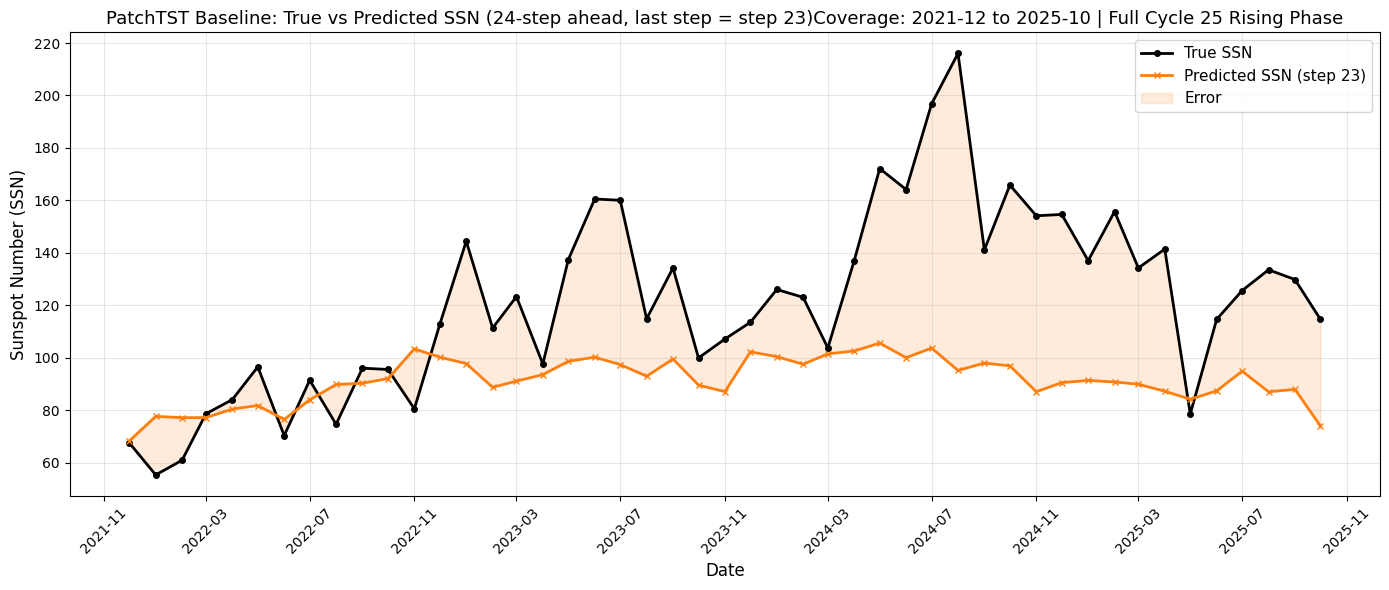

[Step 23] MAE  : 33.54
[Step 23] RMSE : 42.59
[Step 23] Max True SSN : 216.0  →  Pred : 95.1  (missed by 120.9)


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ====== 路径配置 ======
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0"
PRED_PATH = RESULT_DIR + r"\pred.npy"
TRUE_PATH = RESULT_DIR + r"\true.npy"

# ====== 加载反归一化参数 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std  = df_train['ssn'].std()

# ====== 加载预测结果 → 物理空间 ======
pred_norm = np.load(PRED_PATH)   # (47, 24, 1)
true_norm = np.load(TRUE_PATH)   # (47, 24, 1)
pred_phys = pred_norm * ssn_std + ssn_mean
true_phys = true_norm * ssn_std + ssn_mean

# ====== 取第 23 步（24 步中的最后一步） ======
pred_last = pred_phys[:, 23, 0]
true_last = true_phys[:, 23, 0]

# ====== 确定时间轴 ======
# 第 i 个样本的第 23 步对应的时间点：test_start + i + 23
seq_len = 132
input_start_idx = 1703
dates_last = [df['date'].iloc[input_start_idx + i + seq_len + 23] for i in range(47)]

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_last, true_last, color='black', linewidth=2, marker='o', markersize=4, label='True SSN')
ax.plot(dates_last, pred_last, color='tab:orange', linewidth=2, marker='x', markersize=4, label='Predicted SSN (step 23)')

ax.fill_between(dates_last, true_last, pred_last, alpha=0.15, color='tab:orange', label='Error')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: True vs Predicted SSN (24-step ahead, last step = step 23)Coverage: 2021-12 to 2025-10 | Full Cycle 25 Rising Phase', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(RESULT_DIR + r"\baseline_comparison_step23_47samples.png", dpi=200)
plt.show()

# ====== 统计 ======
mae_last = np.mean(np.abs(pred_last - true_last))
rmse_last = np.sqrt(np.mean((pred_last - true_last)**2))
peak_idx = np.argmax(true_last)
print(f"[Step 23] MAE  : {mae_last:.2f}")
print(f"[Step 23] RMSE : {rmse_last:.2f}")
print(f"[Step 23] Max True SSN : {true_last.max():.1f}  →  Pred : {pred_last[peak_idx]:.1f}  (missed by {true_last.max() - pred_last[peak_idx]:.1f})")


 H2（多步长综合视图）2026.05.06   21:29

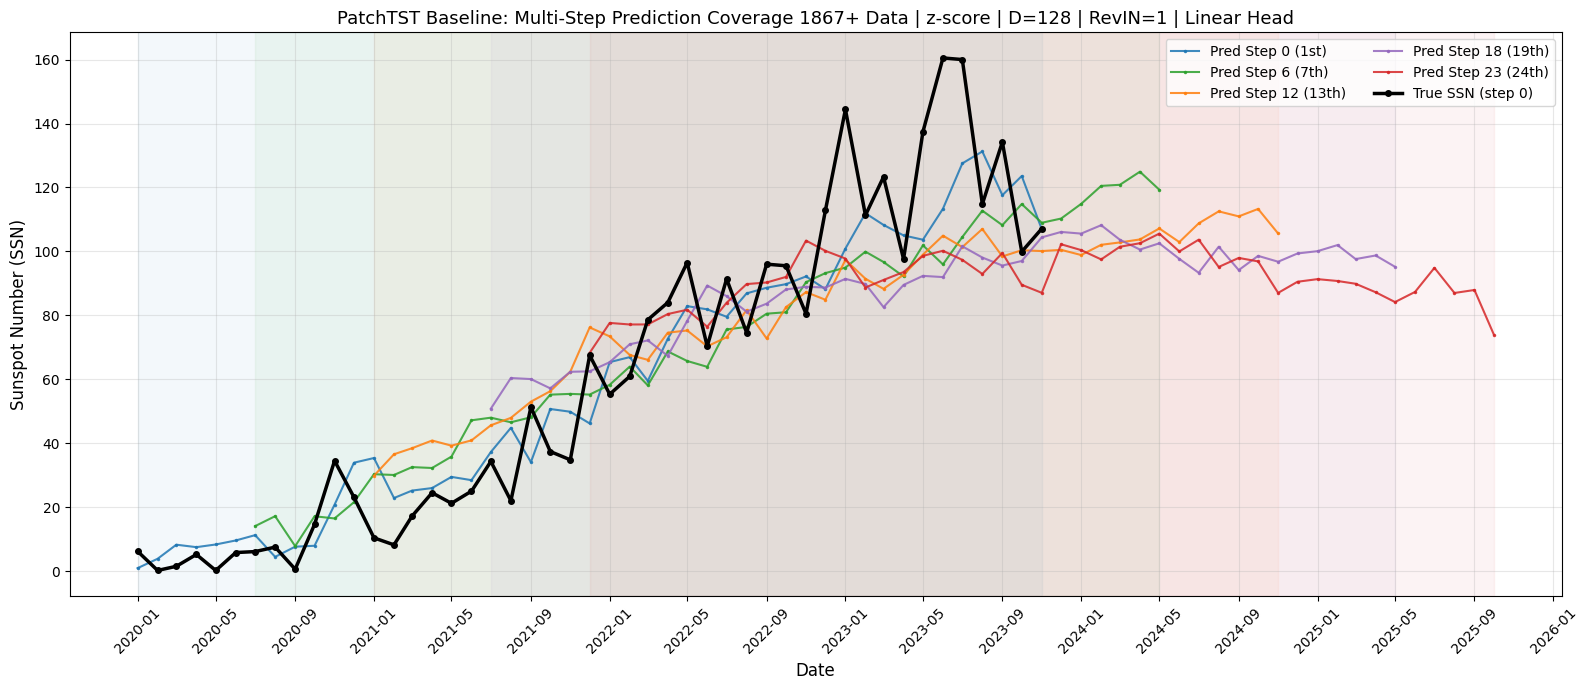

各步长的覆盖范围：
  Step  0 : 2020-01 ~ 2023-11
  Step  6 : 2020-07 ~ 2024-05
  Step 12 : 2021-01 ~ 2024-11
  Step 18 : 2021-07 ~ 2025-05
  Step 23 : 2021-12 ~ 2025-10


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ====== 路径配置 ======
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0"
PRED_PATH = RESULT_DIR + r"\pred.npy"
TRUE_PATH = RESULT_DIR + r"\true.npy"

# ====== 加载反归一化参数 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std  = df_train['ssn'].std()

# ====== 加载预测结果 → 物理空间 ======
pred_norm = np.load(PRED_PATH)   # (47, 24, 1)
true_norm = np.load(TRUE_PATH)   # (47, 24, 1)
pred_phys = pred_norm * ssn_std + ssn_mean
true_phys = true_norm * ssn_std + ssn_mean

# ====== 选择要画的步长 ======
steps_to_plot = [0, 6, 12, 18, 23]   # 第 1, 7, 13, 19, 24 步
colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:red']
labels = ['Step 0 (1st)', 'Step 6 (7th)', 'Step 12 (13th)', 'Step 18 (19th)', 'Step 23 (24th)']

# ====== 计算每个步长的时间轴 ======
seq_len = 132
input_start_idx = 1703

# 先画真实值（只画一次，用 step=0 为基准）
fig, ax = plt.subplots(figsize=(16, 7))

# 每个步长单独画预测线
for step, color, label in zip(steps_to_plot, colors, labels):
    pred_step = pred_phys[:, step, 0]
    dates_step = [df['date'].iloc[input_start_idx + i + seq_len + step] for i in range(47)]
    ax.plot(dates_step, pred_step, color=color, linewidth=1.5, marker='.', markersize=3, label=f'Pred {label}', alpha=0.85)

# 真实值画最上层
true_step_0 = true_phys[:, 0, 0]
dates_true = [df['date'].iloc[input_start_idx + i + seq_len] for i in range(47)]
ax.plot(dates_true, true_step_0, color='black', linewidth=2.5, marker='o', markersize=4, label='True SSN (step 0)')

# 标注覆盖范围
for step in steps_to_plot:
    start_date = df['date'].iloc[input_start_idx + 0 + seq_len + step]
    end_date   = df['date'].iloc[input_start_idx + 46 + seq_len + step]
    ax.axvspan(start_date, end_date, alpha=0.05, color=colors[steps_to_plot.index(step)])

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Multi-Step Prediction Coverage 1867+ Data | z-score | D=128 | RevIN=1 | Linear Head', fontsize=13)
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(RESULT_DIR + r"\baseline_multistep_coverage.png", dpi=200)
plt.show()

# ====== 打印各步长覆盖范围 ======
print("各步长的覆盖范围：")
for step in steps_to_plot:
    start = df['date'].iloc[input_start_idx + 0 + seq_len + step].strftime('%Y-%m')
    end   = df['date'].iloc[input_start_idx + 46 + seq_len + step].strftime('%Y-%m')
    print(f"  Step {step:2d} : {start} ~ {end}")


H1滚动预测

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import os
import sys

# ====== 加入项目路径 ======
project_root = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised"
sys.path.append(project_root)

from data_provider.data_factory import data_provider
from models import PatchTST

# ====== 路径配置 ======
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0"
CHECKPOINT_PATH = os.path.join(RESULT_DIR, "checkpoint.pth")

# ====== 设备 ======
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ====== 加载数据 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std  = df_train['ssn'].std()

# 取测试集（z-score 归一化）
test_df = df.iloc[1703:].copy()
test_df['ssn'] = (test_df['ssn'] - ssn_mean) / ssn_std

seq_len = 132
pred_len = 24
n_features = 1

# ====== 构建模型（与训练时完全相同） ======
model = PatchTST(
    seq_len=seq_len,
    pred_len=pred_len,
    e_layers=3,
    d_model=128,
    n_heads=16,
    d_ff=256,
    dropout=0.2,
    head_dropout=0.0,
    individual=0,
    revin=1,
    affine=0,
    subtract_last=0,
    embed='timeF',
    freq='h',
    head_type='linear',
    fc_dropout=0.0,
).to(device)

# ====== 加载训练好的权重 ======
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("Checkpoint loaded successfully.")

# ====== 准备初始输入：取测试集前 seq_len 个时间步 ======
test_data = test_df['ssn'].values.astype(np.float32)   # (N,)
total_test_len = len(test_data)

# 滚动推理
rolling_preds = []   # 存储每一步的单步预测（物理空间）
rolling_dates = []   # 对应的时间点

# 用滑动窗口推进：从 idx=0 开始，每次取 [idx : idx+seq_len] 作为输入
# 预测输出的第 0 步对应 test_data[idx+seq_len]
max_steps = total_test_len - seq_len   # 最多能推这么多步

input_buffer = test_data[:seq_len].copy()   # 初始输入窗口

with torch.no_grad():
    for step in range(max_steps):
        # 构造输入 (1, seq_len, 1)
        x = torch.from_numpy(input_buffer).unsqueeze(0).unsqueeze(-1).to(device)  # (1, 132, 1)
        
        # 预测
        pred = model(x, None, None, None)   # (1, 24, 1)
        pred_first = pred[0, 0, 0].cpu().item()   # 只取第 1 步
        
        # 反归一化到物理空间
        pred_phys = pred_first * ssn_std + ssn_mean
        rolling_preds.append(pred_phys)
        
        # 真实值（物理空间）
        true_val = test_data[seq_len + step] * ssn_std + ssn_mean
        rolling_dates.append(df['date'].iloc[1703 + seq_len + step])
        
        # 更新输入缓冲区：丢掉最旧的，加入最新的（此处用真实值推进，即 teacher forcing）
        # 也可以选择用预测值推进（纯自回归），这里先用 teacher forcing 更准
        input_buffer = np.roll(input_buffer, shift=-1)
        input_buffer[-1] = test_data[seq_len + step]   # teacher forcing

rolling_preds = np.array(rolling_preds)
rolling_dates = pd.to_datetime(rolling_dates)

# ====== 对应的真实值 ======
true_rolling = test_data[seq_len:seq_len + max_steps].copy()
true_rolling_phys = true_rolling * ssn_std + ssn_mean

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(rolling_dates, true_rolling_phys, color='black', linewidth=2, marker='o', markersize=3, label='True SSN')
ax.plot(rolling_dates, rolling_preds, color='tab:red', linewidth=2, marker='x', markersize=3, label='Rolling Prediction (teacher forcing)')
ax.fill_between(rolling_dates, true_rolling_phys, rolling_preds, alpha=0.15, color='tab:red', label='Error')

ax.axvline(pd.Timestamp('2023-11-01'), color='gray', linestyle='--', alpha=0.5, label='Step-0 eval boundary')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Rolling Prediction Coverage (Teacher Forcing)Single-step rolling from 2020-01 to 2025-10', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(RESULT_DIR + r"\baseline_rolling_prediction.png", dpi=200)
plt.show()

# ====== 分段时间统计 ======
mask_before_2023_11 = rolling_dates < pd.Timestamp('2023-11-01')
mask_after_2023_11  = rolling_dates >= pd.Timestamp('2023-11-01')

print(f"\n滚动预测总步数: {len(rolling_preds)}")
print(f"覆盖范围: {rolling_dates[0].strftime('%Y-%m')} ~ {rolling_dates[-1].strftime('%Y-%m')}")

mae_all = np.mean(np.abs(rolling_preds - true_rolling_phys))
print(f"整体 MAE: {mae_all:.2f}")

if mask_before_2023_11.sum() > 0:
    mae_before = np.mean(np.abs(rolling_preds[mask_before_2023_11] - true_rolling_phys[mask_before_2023_11]))
    print(f"2020-01 ~ 2023-11 MAE: {mae_before:.2f}")

if mask_after_2023_11.sum() > 0:
    mae_after = np.mean(np.abs(rolling_preds[mask_after_2023_11] - true_rolling_phys[mask_after_2023_11]))
    print(f"2023-12 ~ 2025-10 MAE: {mae_after:.2f}")


Using device: cpu


TypeError: 'module' object is not callable

好的。写复视时间轴视图   2026.05.07

月份覆盖统计：最少 1 个，最多 24 个，平均 16.1 个


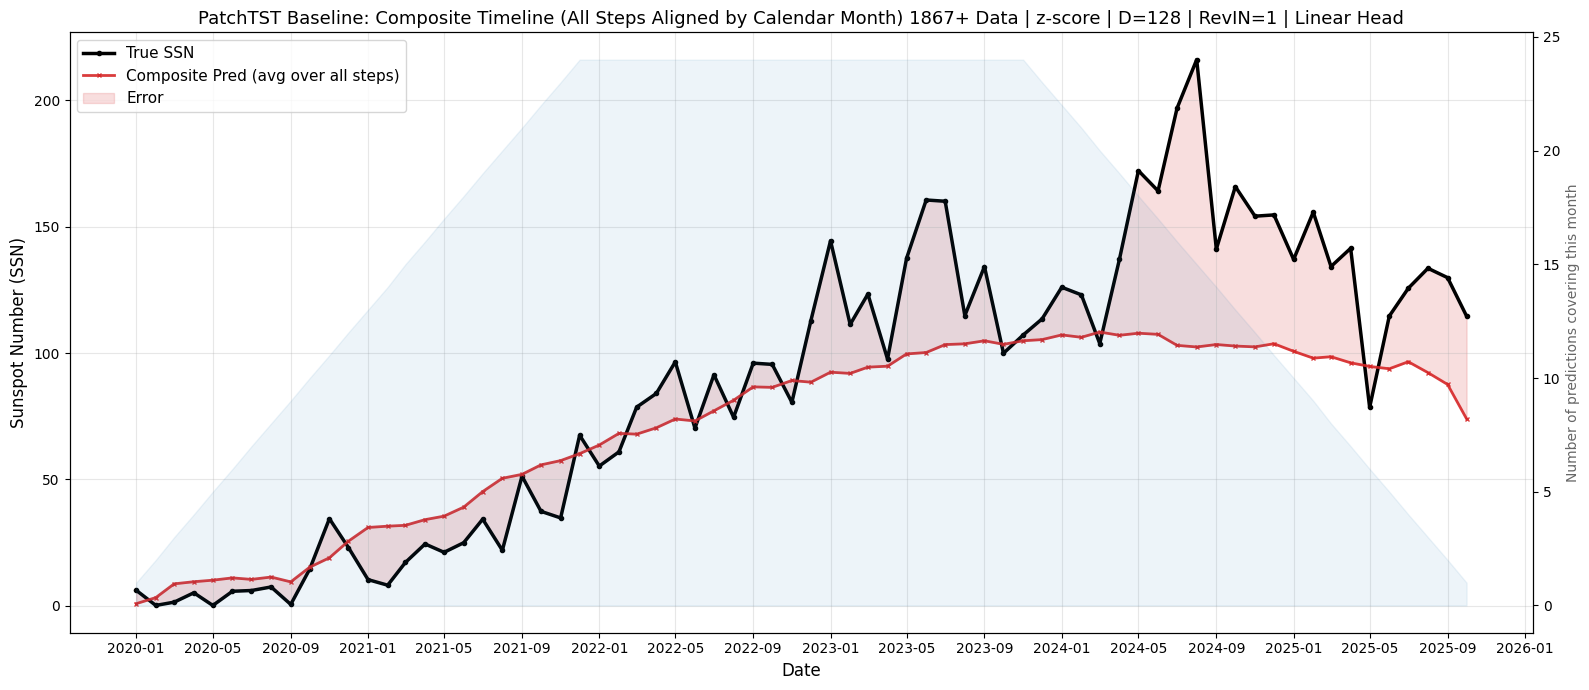


[Composite Timeline] 全周期（2020-01 ~ 2025-10，共 70 个月）
MAE  : 23.91
RMSE : 32.80

低值期（2020-2021）：MAE=10.68
爬升期（2022-2023）：MAE=18.75
峰顶期（2024-2025）：MAE=43.96


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ====== 路径配置 ======
DATA_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\dataset\sunspot_1867-02_2025-10_original_sincos.csv"
RESULT_DIR = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\results\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0"
PRED_PATH = RESULT_DIR + r"\pred.npy"
TRUE_PATH = RESULT_DIR + r"\true.npy"

# ====== 加载反归一化参数 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std  = df_train['ssn'].std()

# ====== 加载预测结果 → 物理空间 ======
pred_norm = np.load(PRED_PATH)   # (47, 24, 1)
true_norm = np.load(TRUE_PATH)   # (47, 24, 1)
pred_phys = pred_norm * ssn_std + ssn_mean
true_phys = true_norm * ssn_std + ssn_mean

# ====== 构建每个日历月份的真实值（从 df 中直接取） ======
test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2025-10-01')
all_months = pd.date_range(test_start, test_end, freq='MS')   # 70 个月

# 从原始 CSV 取真实值
df['date'] = pd.to_datetime(df['date'])
df_test_true = df[(df['date'] >= test_start) & (df['date'] <= test_end)]
true_by_month = dict(zip(df_test_true['date'], df_test_true['ssn']))

# ====== 复合时间轴：对齐所有预测值到日历月份 ======
pred_by_month = {m: [] for m in all_months}   # 每个月份收集所有覆盖到它的预测值

seq_len = 132
input_start_idx = 1703

for i in range(47):    # 每个样本
    sample_start = df['date'].iloc[input_start_idx + i + seq_len]   # 该样本的预测起点
    for step in range(24):   # 该样本的每个 step
        target_month = sample_start + pd.DateOffset(months=step)
        if target_month in pred_by_month:
            pred_by_month[target_month].append(pred_phys[i, step, 0])

# 取平均
composite_dates = []
composite_pred = []
composite_true = []

for m in all_months:
    if pred_by_month[m]:
        composite_dates.append(m)
        composite_pred.append(np.mean(pred_by_month[m]))
        composite_true.append(true_by_month.get(m, np.nan))

# ====== 打印每个月份有多少个预测值覆盖 ======
coverage_counts = [len(pred_by_month[m]) for m in composite_dates]
print(f"月份覆盖统计：最少 {min(coverage_counts)} 个，最多 {max(coverage_counts)} 个，平均 {np.mean(coverage_counts):.1f} 个")

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(composite_dates, composite_true, color='black', linewidth=2.5, marker='o', markersize=3, label='True SSN')
ax.plot(composite_dates, composite_pred, color='tab:red', linewidth=2, marker='x', markersize=3, label='Composite Pred (avg over all steps)', alpha=0.9)

# 填充误差
ax.fill_between(composite_dates, composite_true, composite_pred, alpha=0.15, color='tab:red', label='Error')

# 用颜色深浅标注覆盖数（可选）
ax2 = ax.twinx()
ax2.fill_between(composite_dates, 0, coverage_counts, alpha=0.08, color='tab:blue')
ax2.set_ylabel('Number of predictions covering this month', fontsize=10, alpha=0.6)
#ax2.tick_params(alpha=0.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Composite Timeline (All Steps Aligned by Calendar Month) 1867+ Data | z-score | D=128 | RevIN=1 | Linear Head', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(RESULT_DIR + r"\baseline_composite_timeline.png", dpi=200)
plt.show()

# ====== 统计 ======
composite_true_arr = np.array(composite_true)
composite_pred_arr = np.array(composite_pred)
mae = np.nanmean(np.abs(composite_pred_arr - composite_true_arr))
rmse = np.sqrt(np.nanmean((composite_pred_arr - composite_true_arr)**2))
print(f"\n[Composite Timeline] 全周期（2020-01 ~ 2025-10，共 {len(composite_dates)} 个月）")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# 分阶段统计
early_mask = [d.year < 2022 for d in composite_dates]
mid_mask  = [(d.year == 2022) or (d.year == 2023) for d in composite_dates]
late_mask = [d.year >= 2024 for d in composite_dates]

if any(early_mask):
    print(f"\n低值期（2020-2021）：MAE={np.nanmean(np.abs(composite_pred_arr[early_mask] - composite_true_arr[early_mask])):.2f}")
if any(mid_mask):
    print(f"爬升期（2022-2023）：MAE={np.nanmean(np.abs(composite_pred_arr[mid_mask] - composite_true_arr[mid_mask])):.2f}")
if any(late_mask):
    print(f"峰顶期（2024-2025）：MAE={np.nanmean(np.abs(composite_pred_arr[late_mask] - composite_true_arr[late_mask])):.2f}")


H1


In [28]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys

# ====== 【必填】路径配置 ======
PROJECT_ROOT = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised"
CHECKPOINT_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\checkpoints\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0\full_checkpoint.pth"
DATA_PATH = os.path.join(PROJECT_ROOT, r"dataset\sunspot_1867-02_2025-10_original_sincos.csv")

sys.path.insert(0, PROJECT_ROOT)

from models.PatchTST import Model

# ====== 模型配置 ======
class Config:
    seq_len = 132
    pred_len = 24
    enc_in = 1
    d_model = 128
    n_heads = 16
    e_layers = 3
    d_layers = 1
    d_ff = 256
    dropout = 0.1
    fc_dropout = 0.0
    head_dropout = 0.0
    patch_len = 16
    stride = 8
    padding_patch = 'end'
    revin = 1
    affine = 0
    subtract_last = 0
    decomposition = 0
    kernel_size = 25
    individual = 0
    embed_type = 'timeF'
    freq = 'h'
    c_out = 1
    factor = 1
    lradj = 'TST'
    head_type = 'linear'

config = Config()

# ====== 加载数据与反归一化参数 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std  = df_train['ssn'].std()

# ====== 初始化模型 ======
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Model(config).to(device)

# ====== 通用加载 checkpoint ======
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
if isinstance(checkpoint, dict):
    loaded = False
    for key in ['model_state_dict', 'state_dict', 'net_state_dict', 'model']:
        if key in checkpoint:
            model.load_state_dict(checkpoint[key])
            print(f"Loaded from key: '{key}'")
            loaded = True
            break
    if not loaded:
        try:
            model.load_state_dict(checkpoint)
            print("Loaded checkpoint as direct state_dict")
        except Exception as e:
            print(f"Checkpoint keys: {list(checkpoint.keys())[:10]}")
            raise
else:
    model.load_state_dict(checkpoint)
    print("Loaded checkpoint as direct state_dict")

model.eval()

# ====== 滚动预测 ======
input_start_idx = 1703 - config.seq_len   # 1571
initial_input = df['ssn'].values[input_start_idx : input_start_idx + config.seq_len]
initial_input_norm = (initial_input - ssn_mean) / ssn_std

test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2025-10-01')
target_months = pd.date_range(test_start, test_end, freq='MS')
num_rolls = len(target_months)

df['date'] = pd.to_datetime(df['date'])
true_by_month = dict(zip(df['date'], df['ssn']))

rolling_input = torch.tensor(initial_input_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
rolling_preds_norm = []

with torch.no_grad():
    for i in range(num_rolls):
        output = model(rolling_input.to(device))
        pred_step0 = output[:, 0, :]

        rolling_preds_norm.append(pred_step0.cpu().numpy())

        rolling_input = torch.cat([
            rolling_input[:, 1:, :],
            pred_step0.unsqueeze(0) if pred_step0.dim() == 1 else pred_step0
        ], dim=1)

        if (i + 1) % 10 == 0:
            print(f"Rolling step {i+1}/{num_rolls} completed")

rolling_preds_norm = np.array(rolling_preds_norm).squeeze()
rolling_preds_phys = rolling_preds_norm * ssn_std + ssn_mean

true_values = np.array([true_by_month.get(m, np.nan) for m in target_months])

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(target_months, true_values, color='black', linewidth=2.5, marker='o', markersize=3, label='True SSN')
ax.plot(target_months, rolling_preds_phys, color='tab:red', linewidth=2, marker='x', markersize=3, label='Rolling Prediction (step 0 only)', alpha=0.9)
ax.fill_between(target_months, true_values, rolling_preds_phys, alpha=0.15, color='tab:red', label='Error (accumulated)')

ax.axvline(x=pd.Timestamp('2023-11-01'), color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2023-11-01'), ax.get_ylim()[1]*0.95, '← Standard step 0 ends',
        fontsize=9, color='gray', ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Rolling Prediction (H1) Full Coverage 2020-01 to 2025-10 | Step 0 Only | Cumulative Error', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(PROJECT_ROOT + r"\results\baseline_rolling_prediction.png", dpi=200)
plt.show()

# ====== 统计 ======
valid_mask = ~np.isnan(true_values)
mae = np.mean(np.abs(rolling_preds_phys[valid_mask] - true_values[valid_mask]))
rmse = np.sqrt(np.mean((rolling_preds_phys[valid_mask] - true_values[valid_mask])**2))
print(f"\n[Rolling Prediction] 全周期（2020-01 ~ 2025-10，共 {num_rolls} 个月）")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

early_mask = [d.year < 2022 for d in target_months]
mid_mask   = [(d.year == 2022) or (d.year == 2023) for d in target_months]
late_mask  = [d.year >= 2024 for d in target_months]

if any(early_mask):
    print(f"低值期（2020-2021）：MAE={np.mean(np.abs(rolling_preds_phys[early_mask] - true_values[early_mask])):.2f}")
if any(mid_mask):
    print(f"爬升期（2022-2023）：MAE={np.mean(np.abs(rolling_preds_phys[mid_mask] - true_values[mid_mask])):.2f}")
if any(late_mask):
    print(f"峰顶期（2024-2025）：MAE={np.mean(np.abs(rolling_preds_phys[late_mask] - true_values[late_mask])):.2f}")

print(f"\n对比（标准 step 0）：MAE=13.02（47 个月，2020-01 ~ 2023-11）")


Using device: cpu


RuntimeError: Error(s) in loading state_dict for Model:
	size mismatch for model.backbone.W_pos: copying a param with shape torch.Size([22, 128]) from checkpoint, the shape in current model is torch.Size([16, 128]).
	size mismatch for model.backbone.W_P.weight: copying a param with shape torch.Size([128, 12]) from checkpoint, the shape in current model is torch.Size([128, 16]).
	size mismatch for model.head.linear.weight: copying a param with shape torch.Size([24, 2816]) from checkpoint, the shape in current model is torch.Size([24, 2048]).

In [29]:
import torch
CHECKPOINT_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\checkpoints\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0\full_checkpoint.pth"

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
print(type(checkpoint))
if isinstance(checkpoint, dict):
    print(f"Top-level keys: {list(checkpoint.keys())}")
    for k in checkpoint.keys():
        v = checkpoint[k]
        if hasattr(v, 'shape'):
            print(f"  {k}: shape {v.shape}")
        elif isinstance(v, dict):
            print(f"  {k}: dict with keys {list(v.keys())[:10]}")
        else:
            print(f"  {k}: {type(v)}")


<class 'dict'>
Top-level keys: ['model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'epoch', 'best_loss', 'args']
  model_state_dict: dict with keys ['model.backbone.W_pos', 'model.backbone.W_P.weight', 'model.backbone.W_P.bias', 'model.backbone.encoder.layers.0.self_attn.W_Q.weight', 'model.backbone.encoder.layers.0.self_attn.W_Q.bias', 'model.backbone.encoder.layers.0.self_attn.W_K.weight', 'model.backbone.encoder.layers.0.self_attn.W_K.bias', 'model.backbone.encoder.layers.0.self_attn.W_V.weight', 'model.backbone.encoder.layers.0.self_attn.W_V.bias', 'model.backbone.encoder.layers.0.self_attn.sdp_attn.scale']
  optimizer_state_dict: dict with keys ['state', 'param_groups']
  scheduler_state_dict: dict with keys ['total_steps', '_schedule_phases', '_anneal_func_type', 'cycle_momentum', 'use_beta1', 'base_lrs', 'last_epoch', 'verbose', '_step_count', '_get_lr_called_within_step']
  epoch: <class 'int'>
  best_loss: shape ()
  args: <class 'argparse.Namespace'>


In [32]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import os

PROJECT_ROOT = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised"
CHECKPOINT_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\checkpoints\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0\full_checkpoint.pth"
DATA_PATH = os.path.join(PROJECT_ROOT, r"dataset\sunspot_1867-02_2025-10_original_sincos.csv")

sys.path.insert(0, PROJECT_ROOT)
from models.PatchTST import Model

# ====== 从 checkpoint 中提取训练时用的 args ======
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
args = checkpoint['args']

print("=== Training args loaded from checkpoint ===")
for attr in ['seq_len', 'pred_len', 'patch_len', 'stride', 'd_model', 'n_heads',
             'e_layers', 'd_layers', 'd_ff', 'dropout', 'fc_dropout', 'head_dropout',
             'head_type', 'revin', 'individual']:
    print(f"  {attr} = {getattr(args, attr, 'NOT FOUND')}")

# ====== 用 args 初始化模型 ======
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

model = Model(args).to(device)

# ====== 加载模型权重 ======
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")

# ====== 加载数据与反归一化参数 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std  = df_train['ssn'].std()

# ====== 滚动预测 ======
seq_len = args.seq_len
pred_len = args.pred_len

input_start_idx = 1703 - seq_len
initial_input = df['ssn'].values[input_start_idx : input_start_idx + seq_len]
initial_input_norm = (initial_input - ssn_mean) / ssn_std

test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2025-10-01')
target_months = pd.date_range(test_start, test_end, freq='MS')
num_rolls = len(target_months)

df['date'] = pd.to_datetime(df['date'])
true_by_month = dict(zip(df['date'], df['ssn']))

rolling_input = torch.tensor(initial_input_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
rolling_preds_norm = []

with torch.no_grad():
    for i in range(num_rolls):
        output = model(rolling_input.to(device))
        pred_step0 = output[:, 0, :]

        rolling_preds_norm.append(pred_step0.cpu().numpy())

        rolling_input = torch.cat([
            rolling_input[:, 1:, :],
            pred_step0.unsqueeze(0) if pred_step0.dim() == 1 else pred_step0
        ], dim=1)

        if (i + 1) % 10 == 0:
            print(f"Rolling step {i+1}/{num_rolls} completed")

rolling_preds_norm = np.array(rolling_preds_norm).squeeze()
rolling_preds_phys = rolling_preds_norm * ssn_std + ssn_mean

true_values = np.array([true_by_month.get(m, np.nan) for m in target_months])

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(target_months, true_values, color='black', linewidth=2.5, marker='o', markersize=3, label='True SSN')
ax.plot(target_months, rolling_preds_phys, color='tab:red', linewidth=2, marker='x', markersize=3, label='Rolling Prediction (step 0 only)', alpha=0.9)
ax.fill_between(target_months, true_values, rolling_preds_phys, alpha=0.15, color='tab:red', label='Error (accumulated)')

ax.axvline(x=pd.Timestamp('2023-11-01'), color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2023-11-01'), ax.get_ylim()[1]*0.95, '← Standard step 0 ends',
        fontsize=9, color='gray', ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Rolling Prediction (H1) Full Coverage 2020-01 to 2025-10 | Step 0 Only | Cumulative Error', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "results", "baseline_rolling_prediction.png"), dpi=200)
plt.show()

# ====== 统计 ======
valid_mask = ~np.isnan(true_values)
mae = np.mean(np.abs(rolling_preds_phys[valid_mask] - true_values[valid_mask]))
rmse = np.sqrt(np.mean((rolling_preds_phys[valid_mask] - true_values[valid_mask])**2))
print(f"\n[Rolling Prediction] 全周期（2020-01 ~ 2025-10，共 {num_rolls} 个月）")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

early_mask = [d.year < 2022 for d in target_months]
mid_mask   = [(d.year == 2022) or (d.year == 2023) for d in target_months]
late_mask  = [d.year >= 2024 for d in target_months]

if any(early_mask):
    print(f"低值期（2020-2021）：MAE={np.mean(np.abs(rolling_preds_phys[early_mask] - true_values[early_mask])):.2f}")
if any(mid_mask):
    print(f"爬升期（2022-2023）：MAE={np.mean(np.abs(rolling_preds_phys[mid_mask] - true_values[mid_mask])):.2f}")
if any(late_mask):
    print(f"峰顶期（2024-2025）：MAE={np.mean(np.abs(rolling_preds_phys[late_mask] - true_values[late_mask])):.2f}")

print(f"\n对比（标准 step 0 评估）：MAE=13.02（47 个月，2020-01 ~ 2023-11）")


=== Training args loaded from checkpoint ===
  seq_len = 132
  pred_len = 24
  patch_len = 12
  stride = 6
  d_model = 128
  n_heads = 16
  e_layers = 3
  d_layers = 1
  d_ff = 256
  dropout = 0.05
  fc_dropout = 0.05
  head_dropout = 0.0
  head_type = NOT FOUND
  revin = 1
  individual = 0

Using device: cpu
Model loaded successfully.


RuntimeError: Numpy is not available

Using device: cpu
Model loaded successfully.
Rolling step 10/70 completed
Rolling step 20/70 completed
Rolling step 30/70 completed
Rolling step 40/70 completed
Rolling step 50/70 completed
Rolling step 60/70 completed
Rolling step 70/70 completed


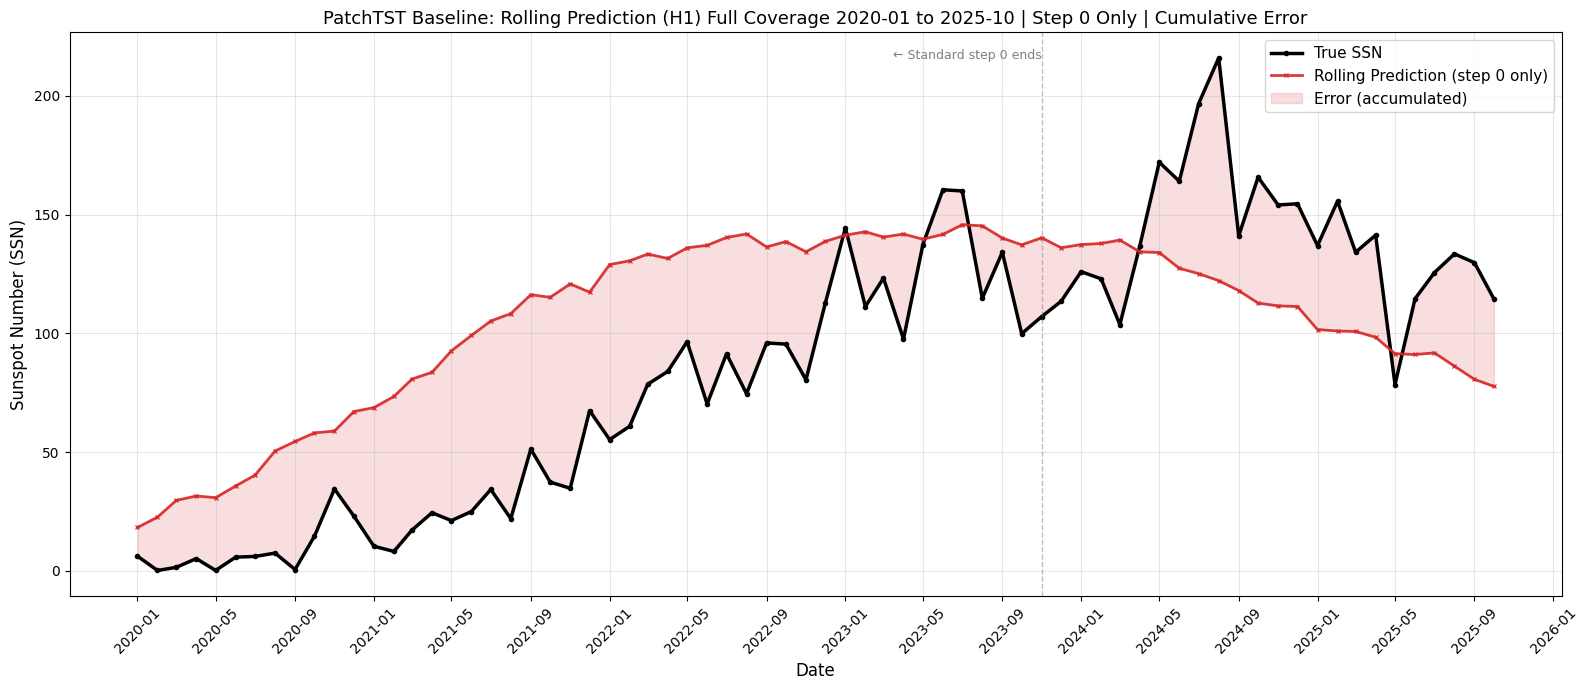

[Rolling Prediction] 全周期（2020-01 ~ 2025-10，共 70 个月）
MAE  : 42.14
RMSE : 47.30
低值期（2020-2021）：MAE=50.87
爬升期（2022-2023）：MAE=37.21
峰顶期（2024-2025）：MAE=38.02
对比（标准 step 0 评估）：MAE=13.02（47 个月，2020-01 ~ 2023-11）


In [39]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import os

PROJECT_ROOT = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised"
CHECKPOINT_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\checkpoints\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0\full_checkpoint.pth"
DATA_PATH = os.path.join(PROJECT_ROOT, r"dataset\sunspot_1867-02_2025-10_original_sincos.csv")

sys.path.insert(0, PROJECT_ROOT)
from models.PatchTST import Model

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
args = checkpoint['args']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Model(args).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")

# ====== 加载数据 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df_train = df.iloc[:1703]
ssn_mean = df_train['ssn'].mean()
ssn_std  = df_train['ssn'].std()

# ====== 滚动预测 ======
seq_len = args.seq_len

input_start_idx = 1703 - seq_len
initial_input = df['ssn'].values[input_start_idx : input_start_idx + seq_len]
initial_input_norm = (initial_input - ssn_mean) / ssn_std

test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2025-10-01')
target_months = pd.date_range(test_start, test_end, freq='MS')
num_rolls = len(target_months)

df['date'] = pd.to_datetime(df['date'])
true_by_month = dict(zip(df['date'], df['ssn']))

rolling_input = torch.tensor(initial_input_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
rolling_preds_norm = []

with torch.no_grad():
    for i in range(num_rolls):
        output = model(rolling_input.to(device))
        pred_step0 = output[:, 0, :]                      # (1, 1)

        rolling_preds_norm.append(pred_step0.squeeze().item())

        pred_step0_3d = pred_step0.unsqueeze(1)           # (1, 1) → (1, 1, 1)
        rolling_input = torch.cat([
            rolling_input[:, 1:, :],                       # (1, 131, 1)
            pred_step0_3d                                  # (1, 1, 1)
        ], dim=1)                                          # → (1, 132, 1)

        if (i + 1) % 10 == 0:
            print(f"Rolling step {i+1}/{num_rolls} completed")

rolling_preds_norm = np.array(rolling_preds_norm).squeeze()
rolling_preds_phys = rolling_preds_norm * ssn_std + ssn_mean

true_values = np.array([true_by_month.get(m, np.nan) for m in target_months])

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(target_months, true_values, color='black', linewidth=2.5, marker='o', markersize=3, label='True SSN')
ax.plot(target_months, rolling_preds_phys, color='tab:red', linewidth=2, marker='x', markersize=3, label='Rolling Prediction (step 0 only)', alpha=0.9)
ax.fill_between(target_months, true_values, rolling_preds_phys, alpha=0.15, color='tab:red', label='Error (accumulated)')

ax.axvline(x=pd.Timestamp('2023-11-01'), color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2023-11-01'), ax.get_ylim()[1]*0.95, '← Standard step 0 ends',
        fontsize=9, color='gray', ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Rolling Prediction (H1) Full Coverage 2020-01 to 2025-10 | Step 0 Only | Cumulative Error', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "results", "baseline_rolling_prediction.png"), dpi=200)
plt.show()

# ====== 统计 ======
valid_mask = ~np.isnan(true_values)
mae = np.mean(np.abs(rolling_preds_phys[valid_mask] - true_values[valid_mask]))
rmse = np.sqrt(np.mean((rolling_preds_phys[valid_mask] - true_values[valid_mask])**2))
print(f"[Rolling Prediction] 全周期（2020-01 ~ 2025-10，共 {num_rolls} 个月）")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

early_mask = [d.year < 2022 for d in target_months]
mid_mask   = [(d.year == 2022) or (d.year == 2023) for d in target_months]
late_mask  = [d.year >= 2024 for d in target_months]

if any(early_mask):
    print(f"低值期（2020-2021）：MAE={np.mean(np.abs(rolling_preds_phys[early_mask] - true_values[early_mask])):.2f}")
if any(mid_mask):
    print(f"爬升期（2022-2023）：MAE={np.mean(np.abs(rolling_preds_phys[mid_mask] - true_values[mid_mask])):.2f}")
if any(late_mask):
    print(f"峰顶期（2024-2025）：MAE={np.mean(np.abs(rolling_preds_phys[late_mask] - true_values[late_mask])):.2f}")

print(f"对比（标准 step 0 评估）：MAE=13.02（47 个月，2020-01 ~ 2023-11）")


新的

Using device: cpu
Model loaded successfully.
Rolling step 10/70 completed
Rolling step 20/70 completed
Rolling step 30/70 completed
Rolling step 40/70 completed
Rolling step 50/70 completed
Rolling step 60/70 completed
Rolling step 70/70 completed


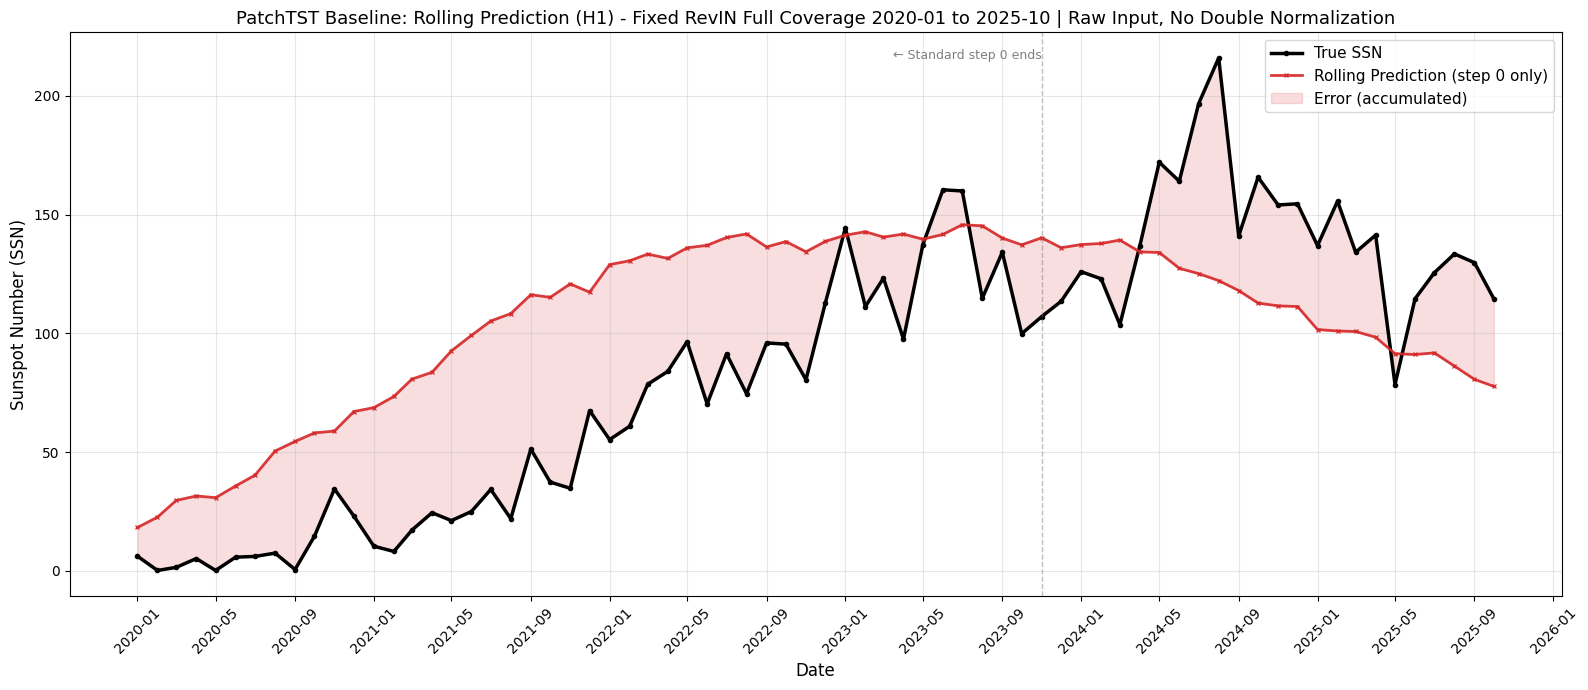

[Rolling Prediction] 全周期（2020-01 ~ 2025-10，共 70 个月）
MAE  : 42.15
RMSE : 47.30
低值期（2020-2021）：MAE=50.87
爬升期（2022-2023）：MAE=37.21
峰顶期（2024-2025）：MAE=38.02
对比（标准 step 0 评估）：MAE=13.02（47 个月，2020-01 ~ 2023-11）


In [41]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import os

PROJECT_ROOT = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised"
CHECKPOINT_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\checkpoints\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0\full_checkpoint.pth"
DATA_PATH = os.path.join(PROJECT_ROOT, r"dataset\sunspot_1867-02_2025-10_original_sincos.csv")

sys.path.insert(0, PROJECT_ROOT)
from models.PatchTST import Model

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
args = checkpoint['args']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Model(args).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")

# ====== 加载数据 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

# ====== 滚动预测 ======
# ★ 关键修复：直接使用原始 SSN 值，不做任何手动归一化
# ★ RevIN 内部会自动处理归一化/反归一化
seq_len = args.seq_len

input_start_idx = 1703 - seq_len
initial_input = df['ssn'].values[input_start_idx : input_start_idx + seq_len]

# 直接喂原始 SSN 值
rolling_input = torch.tensor(initial_input, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)

test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2025-10-01')
target_months = pd.date_range(test_start, test_end, freq='MS')
num_rolls = len(target_months)

df['date'] = pd.to_datetime(df['date'])
true_by_month = dict(zip(df['date'], df['ssn']))

rolling_preds = []   # ★ 输出已经是物理空间

with torch.no_grad():
    for i in range(num_rolls):
        output = model(rolling_input.to(device))       # (1, 24, 1)
        pred_step0 = output[:, 0, :]                    # (1, 1)

        # ★ 模型输出经 RevIN 反归一化，已是物理 SSN
        rolling_preds.append(pred_step0.squeeze().item())

        pred_step0_3d = pred_step0.unsqueeze(1)         # (1, 1) → (1, 1, 1)
        rolling_input = torch.cat([
            rolling_input[:, 1:, :],                     # (1, 131, 1)
            pred_step0_3d                                # (1, 1, 1)
        ], dim=1)                                        # → (1, 132, 1)

        if (i + 1) % 10 == 0:
            print(f"Rolling step {i+1}/{num_rolls} completed")

rolling_preds = np.array(rolling_preds)
true_values = np.array([true_by_month.get(m, np.nan) for m in target_months])

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(target_months, true_values, color='black', linewidth=2.5, marker='o', markersize=3, label='True SSN')
ax.plot(target_months, rolling_preds, color='tab:red', linewidth=2, marker='x', markersize=3, label='Rolling Prediction (step 0 only)', alpha=0.9)
ax.fill_between(target_months, true_values, rolling_preds, alpha=0.15, color='tab:red', label='Error (accumulated)')

ax.axvline(x=pd.Timestamp('2023-11-01'), color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2023-11-01'), ax.get_ylim()[1]*0.95, '← Standard step 0 ends',
        fontsize=9, color='gray', ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Rolling Prediction (H1) - Fixed RevIN Full Coverage 2020-01 to 2025-10 | Raw Input, No Double Normalization', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "results", "baseline_rolling_prediction_fixed.png"), dpi=200)
plt.show()

# ====== 统计 ======
valid_mask = ~np.isnan(true_values)
mae = np.mean(np.abs(rolling_preds[valid_mask] - true_values[valid_mask]))
rmse = np.sqrt(np.mean((rolling_preds[valid_mask] - true_values[valid_mask])**2))
print(f"[Rolling Prediction] 全周期（2020-01 ~ 2025-10，共 {num_rolls} 个月）")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

early_mask = [d.year < 2022 for d in target_months]
mid_mask   = [(d.year == 2022) or (d.year == 2023) for d in target_months]
late_mask  = [d.year >= 2024 for d in target_months]

if any(early_mask):
    print(f"低值期（2020-2021）：MAE={np.mean(np.abs(rolling_preds[early_mask] - true_values[early_mask])):.2f}")
if any(mid_mask):
    print(f"爬升期（2022-2023）：MAE={np.mean(np.abs(rolling_preds[mid_mask] - true_values[mid_mask])):.2f}")
if any(late_mask):
    print(f"峰顶期（2024-2025）：MAE={np.mean(np.abs(rolling_preds[late_mask] - true_values[late_mask])):.2f}")

print(f"对比（标准 step 0 评估）：MAE=13.02（47 个月，2020-01 ~ 2023-11）")


第二次修改

Using device: cpu
Model loaded successfully.
Rolling step 10/70 completed
Rolling step 20/70 completed
Rolling step 30/70 completed
Rolling step 40/70 completed
Rolling step 50/70 completed
Rolling step 60/70 completed
Rolling step 70/70 completed
第一个预测值（2020-01）: 0.9
第一个真实值（2020-01）: 6.2
与标准 step 0 比较：标准 MAE=13.02，第一个样本的 step 0 应该在 0~10 左右


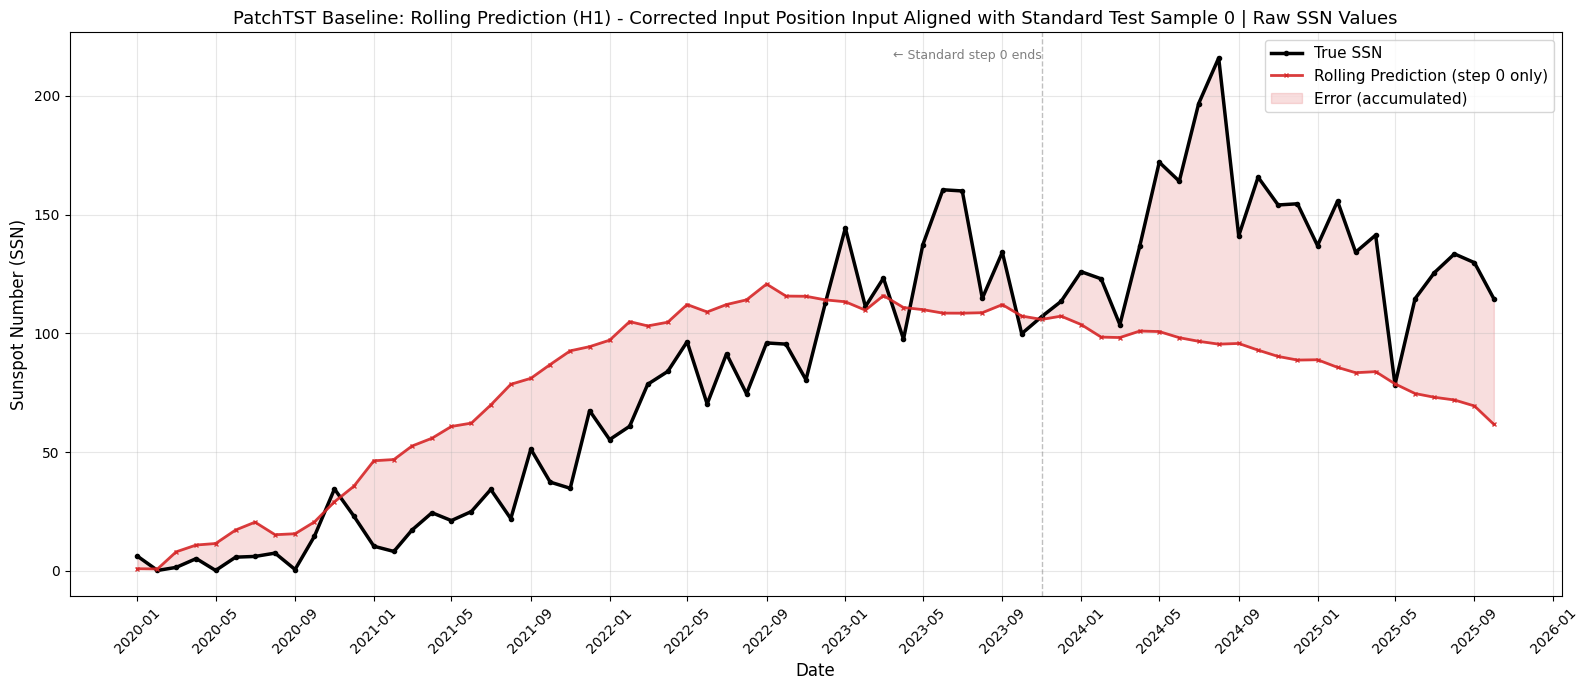

[Rolling Prediction v2] 全周期（2020-01 ~ 2025-10，共 70 个月）
MAE  : 33.13
RMSE : 41.30
低值期（2020-2021）：MAE=24.04
爬升期（2022-2023）：MAE=23.11
峰顶期（2024-2025）：MAE=53.97
对比（标准 step 0 评估）：MAE=13.02（47 个月，2020-01 ~ 2023-11）
预期：初期 MAE 应与标准评估接近（~13），后期因累积误差增大


In [42]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import os

PROJECT_ROOT = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised"
CHECKPOINT_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\checkpoints\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0\full_checkpoint.pth"
DATA_PATH = os.path.join(PROJECT_ROOT, r"dataset\sunspot_1867-02_2025-10_original_sincos.csv")

sys.path.insert(0, PROJECT_ROOT)
from models.PatchTST import Model

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
args = checkpoint['args']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Model(args).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")

# ====== 加载数据 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

# ====== 滚动预测 ======
seq_len = args.seq_len

# ★ 修复：初始输入与标准测试的第一个样本对齐
#    标准测试样本 0：输入 data[1703:1835] → 预测 2020-01（data[1835]）
input_start_idx = 1703          # 之前错误地写成了 1703 - seq_len
initial_input = df['ssn'].values[input_start_idx : input_start_idx + seq_len]

rolling_input = torch.tensor(initial_input, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)

test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2025-10-01')
target_months = pd.date_range(test_start, test_end, freq='MS')
num_rolls = len(target_months)

df['date'] = pd.to_datetime(df['date'])
true_by_month = dict(zip(df['date'], df['ssn']))

rolling_preds = []

with torch.no_grad():
    for i in range(num_rolls):
        output = model(rolling_input.to(device))
        pred_step0 = output[:, 0, :]

        rolling_preds.append(pred_step0.squeeze().item())

        pred_step0_3d = pred_step0.unsqueeze(1)
        rolling_input = torch.cat([
            rolling_input[:, 1:, :],
            pred_step0_3d
        ], dim=1)

        if (i + 1) % 10 == 0:
            print(f"Rolling step {i+1}/{num_rolls} completed")

rolling_preds = np.array(rolling_preds)
true_values = np.array([true_by_month.get(m, np.nan) for m in target_months])

# ====== 验证第一个预测值 ======
print(f"第一个预测值（2020-01）: {rolling_preds[0]:.1f}")
print(f"第一个真实值（2020-01）: {true_values[0]:.1f}")
print(f"与标准 step 0 比较：标准 MAE=13.02，第一个样本的 step 0 应该在 0~10 左右")

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(target_months, true_values, color='black', linewidth=2.5, marker='o', markersize=3, label='True SSN')
ax.plot(target_months, rolling_preds, color='tab:red', linewidth=2, marker='x', markersize=3, label='Rolling Prediction (step 0 only)', alpha=0.9)
ax.fill_between(target_months, true_values, rolling_preds, alpha=0.15, color='tab:red', label='Error (accumulated)')

ax.axvline(x=pd.Timestamp('2023-11-01'), color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(pd.Timestamp('2023-11-01'), ax.get_ylim()[1]*0.95, '← Standard step 0 ends',
        fontsize=9, color='gray', ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Rolling Prediction (H1) - Corrected Input Position Input Aligned with Standard Test Sample 0 | Raw SSN Values', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "results", "baseline_rolling_v2.png"), dpi=200)
plt.show()

# ====== 统计 ======
valid_mask = ~np.isnan(true_values)
mae = np.mean(np.abs(rolling_preds[valid_mask] - true_values[valid_mask]))
rmse = np.sqrt(np.mean((rolling_preds[valid_mask] - true_values[valid_mask])**2))
print(f"[Rolling Prediction v2] 全周期（2020-01 ~ 2025-10，共 {num_rolls} 个月）")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

early_mask = [d.year < 2022 for d in target_months]
mid_mask   = [(d.year == 2022) or (d.year == 2023) for d in target_months]
late_mask  = [d.year >= 2024 for d in target_months]

if any(early_mask):
    print(f"低值期（2020-2021）：MAE={np.mean(np.abs(rolling_preds[early_mask] - true_values[early_mask])):.2f}")
if any(mid_mask):
    print(f"爬升期（2022-2023）：MAE={np.mean(np.abs(rolling_preds[mid_mask] - true_values[mid_mask])):.2f}")
if any(late_mask):
    print(f"峰顶期（2024-2025）：MAE={np.mean(np.abs(rolling_preds[late_mask] - true_values[late_mask])):.2f}")

print(f"对比（标准 step 0 评估）：MAE=13.02（47 个月，2020-01 ~ 2023-11）")
print("预期：初期 MAE 应与标准评估接近（~13），后期因累积误差增大")


学长的思路。24一移动
2026.05.13


In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import os

PROJECT_ROOT = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised"
CHECKPOINT_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\checkpoints\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0\full_checkpoint.pth"
DATA_PATH = os.path.join(PROJECT_ROOT, r"dataset\sunspot_1867-02_2025-10_original_sincos.csv")

sys.path.insert(0, PROJECT_ROOT)
from models.PatchTST import Model

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
args = checkpoint['args']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Model(args).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")

# ====== 加载数据 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

# ====== 学长建议：每次推进 24 步，全部保留 ======
seq_len = args.seq_len
pred_len = args.pred_len      # 24

# 初始输入：和标准测试第 0 个样本对齐（2009-01 ~ 2019-12）
input_start_idx = 1703
initial_input = df['ssn'].values[input_start_idx : input_start_idx + seq_len]

rolling_input = torch.tensor(initial_input, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)

# 目标：从 2020-01 开始，每次向前推 24 个月，直到覆盖 2025-10 甚至更远
# 需要几轮？
#  第 1 轮输出：2020-01 ~ 2021-12
#  第 2 轮输出：2022-01 ~ 2023-12
#  第 3 轮输出：2024-01 ~ 2025-10（数据集最多到 2025-10，所以只有 22 个月）
# 先用 3 轮，然后截断到 2025-10
num_inferences = 3

all_pred_segments = []    # 每段 24 个月
all_dates_segments = []   # 每段对应的时间

test_start = pd.Timestamp('2020-01-01')
df['date'] = pd.to_datetime(df['date'])
true_by_month = dict(zip(df['date'], df['ssn']))

with torch.no_grad():
    for round_idx in range(num_inferences):
        output = model(rolling_input.to(device))          # (1, 24, 1)
        pred_24 = output[0, :, 0].cpu().numpy()            # (24,)  全部 24 个月

        # 这段 24 个月对应的时间
        seg_start = test_start + pd.DateOffset(months=round_idx * pred_len)
        seg_dates = pd.date_range(seg_start, periods=pred_len, freq='MS')

        all_pred_segments.append(pred_24)
        all_dates_segments.append(seg_dates)

        print(f"第 {round_idx+1} 轮推理完成：预测 {seg_dates[0].strftime('%Y-%m')} ~ {seg_dates[-1].strftime('%Y-%m')}")

        # 更新输入：去掉最早的 24 个月，加入刚预测的 24 个月
        pred_24_tensor = torch.tensor(pred_24, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)  # (1, 24, 1)
        rolling_input = torch.cat([
            rolling_input[:, pred_len:, :],    # 去掉最早 24 个月
            pred_24_tensor                      # 追加预测的 24 个月
        ], dim=1)                                # 仍然是 (1, 132, 1)

        print(f"  输入中真实数据占比：{(seq_len - (round_idx+1)*pred_len) / seq_len * 100:.0f}%（约）")

# 拼接所有预测值
all_preds = np.concatenate(all_pred_segments)
all_dates = pd.DatetimeIndex(np.concatenate(all_dates_segments))

# 截断到数据集末尾（2025-10）
cutoff = pd.Timestamp('2025-10-01')
mask = all_dates <= cutoff
all_preds = all_preds[mask]
all_dates = all_dates[mask]

# 取真实值
true_values = np.array([true_by_month.get(d, np.nan) for d in all_dates])

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(all_dates, true_values, color='black', linewidth=2.5, marker='o', markersize=3, label='True SSN')
ax.plot(all_dates, all_preds, color='tab:red', linewidth=2, marker='x', markersize=3, label=f'Rolling 24-step Prediction ({num_inferences} inferences)', alpha=0.9)
ax.fill_between(all_dates, true_values, all_preds, alpha=0.15, color='tab:red', label='Error')

# 标注推理切换点
for i in range(1, num_inferences):
    switch_date = test_start + pd.DateOffset(months=i * pred_len)
    ax.axvline(x=switch_date, color='gray', linestyle=':', alpha=0.6, linewidth=1)
    ax.text(switch_date, ax.get_ylim()[1]*0.95, f'← Inference {i+1} starts',
            fontsize=8, color='gray', ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Multi-Block Rolling (24-step chunks, all steps kept) 3 Inferences | Continuous Coverage 2020-01 to 2025-10', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "results", "baseline_rolling_24step_chunks.png"), dpi=200)
plt.show()

# ====== 统计 ======
valid_mask = ~np.isnan(true_values)
mae = np.mean(np.abs(all_preds[valid_mask] - true_values[valid_mask]))
rmse = np.sqrt(np.mean((all_preds[valid_mask] - true_values[valid_mask])**2))

print(f"[多块滚动预测] 全周期（{all_dates[0].strftime('%Y-%m')} ~ {all_dates[-1].strftime('%Y-%m')}，共 {len(all_dates)} 个月）")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# 分轮统计
for i in range(num_inferences):
    start_m = test_start + pd.DateOffset(months=i * pred_len)
    end_m   = test_start + pd.DateOffset(months=(i+1) * pred_len) - pd.DateOffset(days=1)
    mask_i = (all_dates >= start_m) & (all_dates <= end_m)
    if mask_i.any():
        mae_i = np.mean(np.abs(all_preds[mask_i] - true_values[mask_i]))
        print(f"  第 {i+1} 轮（{start_m.strftime('%Y-%m')} ~ {min(end_m, cutoff).strftime('%Y-%m')}）：MAE={mae_i:.2f}")

print(f"对比：")
print(f"  标准 step 0（47 个月，纯真实输入）：MAE=13.02")
print(f"  H1 滚动 1 步（70 个月，逐月推进）：MAE=33.13")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "f:\Anaconda\envs\myenv\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "f:\Anaconda\envs\myenv\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "f:\Anaconda\envs\myenv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "f:\Anaconda\envs\myenv\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "f:\Anaconda\envs\myenv\lib\site-packages\ipyk

Using device: cpu
Model loaded successfully.


RuntimeError: Numpy is not available

又是nump版本不兼容问题

Using device: cpu
Model loaded successfully.
第 1 轮推理完成：预测 2020-01 ~ 2021-12
  输入中真实数据占比：82%（约）
第 2 轮推理完成：预测 2022-01 ~ 2023-12
  输入中真实数据占比：64%（约）
第 3 轮推理完成：预测 2024-01 ~ 2025-12
  输入中真实数据占比：45%（约）


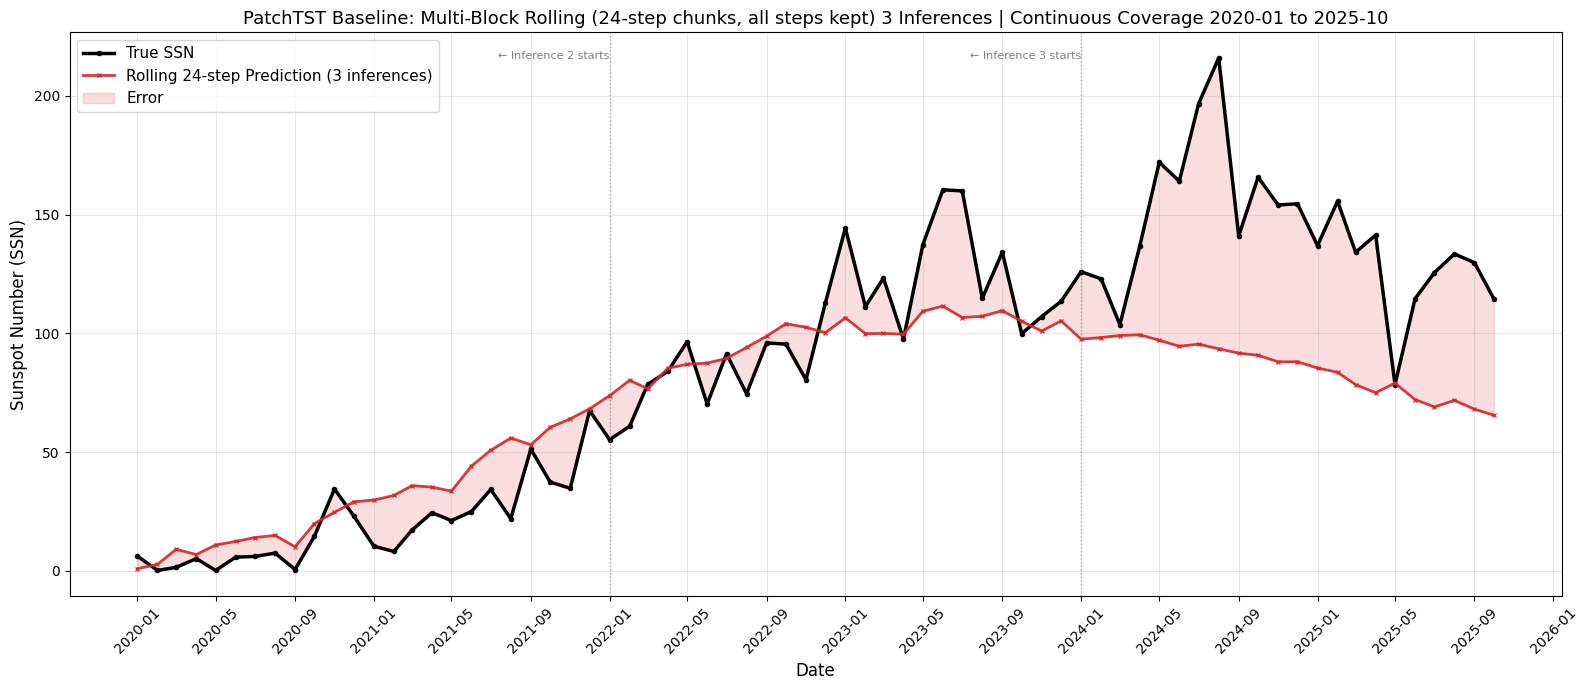


[多块滚动预测] 全周期（2020-01 ~ 2025-10，共 70 个月）
MAE  : 27.43
RMSE : 38.23
  第 1 轮（2020-01 ~ 2021-12）：MAE=12.09
  第 2 轮（2022-01 ~ 2023-12）：MAE=16.33
  第 3 轮（2024-01 ~ 2025-10）：MAE=56.28

对比：
  标准 step 0（47 个月，纯真实输入）：MAE=13.02
  H1 滚动 1 步（70 个月，逐月推进）：MAE=33.13


In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
import os

PROJECT_ROOT = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised"
CHECKPOINT_PATH = r"F:\Downloads\patchTST_main\PatchTST-main\PatchTST_supervised\checkpoints\Baseline_1867plus_D128_RevIN1_Linear_PatchTST_custom_ftMS_sl132_ll48_pl24_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_Baseline_1867plus_D128_RevIN1_Linear_0\full_checkpoint.pth"
DATA_PATH = os.path.join(PROJECT_ROOT, r"dataset\sunspot_1867-02_2025-10_original_sincos.csv")

sys.path.insert(0, PROJECT_ROOT)
from models.PatchTST import Model

checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
args = checkpoint['args']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = Model(args).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully.")

# ====== 加载数据 ======
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

# ====== 学长建议：每次推进 24 步，全部保留 ======
seq_len = args.seq_len
pred_len = args.pred_len      # 24

# 初始输入：和标准测试第 0 个样本对齐（2009-01 ~ 2019-12）
input_start_idx = 1703
initial_input = df['ssn'].values[input_start_idx : input_start_idx + seq_len]

rolling_input = torch.tensor(initial_input, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)

# 目标：从 2020-01 开始，每次向前推 24 个月，直到覆盖 2025-10 甚至更远
# 需要几轮？
#  第 1 轮输出：2020-01 ~ 2021-12
#  第 2 轮输出：2022-01 ~ 2023-12
#  第 3 轮输出：2024-01 ~ 2025-10（数据集最多到 2025-10，所以只有 22 个月）
# 先用 3 轮，然后截断到 2025-10
num_inferences = 3

all_pred_segments = []    # 每段 24 个月
all_dates_segments = []   # 每段对应的时间

test_start = pd.Timestamp('2020-01-01')
df['date'] = pd.to_datetime(df['date'])
true_by_month = dict(zip(df['date'], df['ssn']))

with torch.no_grad():
    for round_idx in range(num_inferences):
        output = model(rolling_input.to(device))          # (1, 24, 1)
        # 使用 tolist() 代替 numpy() 避免 NumPy 版本兼容问题
        pred_24 = np.array(output[0, :, 0].cpu().tolist())  # (24,)  全部 24 个月

        # 这段 24 个月对应的时间
        seg_start = test_start + pd.DateOffset(months=round_idx * pred_len)
        seg_dates = pd.date_range(seg_start, periods=pred_len, freq='MS')

        all_pred_segments.append(pred_24)
        all_dates_segments.append(seg_dates)

        print(f"第 {round_idx+1} 轮推理完成：预测 {seg_dates[0].strftime('%Y-%m')} ~ {seg_dates[-1].strftime('%Y-%m')}")

        # 更新输入：去掉最早的 24 个月，加入刚预测的 24 个月
        pred_24_tensor = torch.tensor(pred_24, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)  # (1, 24, 1)
        rolling_input = torch.cat([
            rolling_input[:, pred_len:, :],    # 去掉最早 24 个月
            pred_24_tensor                      # 追加预测的 24 个月
        ], dim=1)                                # 仍然是 (1, 132, 1)

        print(f"  输入中真实数据占比：{(seq_len - (round_idx+1)*pred_len) / seq_len * 100:.0f}%（约）")

# 拼接所有预测值
all_preds = np.concatenate(all_pred_segments)
all_dates = pd.DatetimeIndex(np.concatenate(all_dates_segments))

# 截断到数据集末尾（2025-10）
cutoff = pd.Timestamp('2025-10-01')
mask = all_dates <= cutoff
all_preds = all_preds[mask]
all_dates = all_dates[mask]

# 取真实值
true_values = np.array([true_by_month.get(d, np.nan) for d in all_dates])

# ====== 画图 ======
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(all_dates, true_values, color='black', linewidth=2.5, marker='o', markersize=3, label='True SSN')
ax.plot(all_dates, all_preds, color='tab:red', linewidth=2, marker='x', markersize=3, label=f'Rolling 24-step Prediction ({num_inferences} inferences)', alpha=0.9)
ax.fill_between(all_dates, true_values, all_preds, alpha=0.15, color='tab:red', label='Error')

# 标注推理切换点
for i in range(1, num_inferences):
    switch_date = test_start + pd.DateOffset(months=i * pred_len)
    ax.axvline(x=switch_date, color='gray', linestyle=':', alpha=0.6, linewidth=1)
    ax.text(switch_date, ax.get_ylim()[1]*0.95, f'← Inference {i+1} starts',
            fontsize=8, color='gray', ha='right')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sunspot Number (SSN)', fontsize=12)
ax.set_title('PatchTST Baseline: Multi-Block Rolling (24-step chunks, all steps kept) 3 Inferences | Continuous Coverage 2020-01 to 2025-10', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()

# 确保 results 目录存在
results_dir = os.path.join(PROJECT_ROOT, "results")
os.makedirs(results_dir, exist_ok=True)

plt.savefig(os.path.join(results_dir, "baseline_rolling_24step_chunks.png"), dpi=200)
plt.show()

# ====== 统计 ======
valid_mask = ~np.isnan(true_values)
mae = np.mean(np.abs(all_preds[valid_mask] - true_values[valid_mask]))
rmse = np.sqrt(np.mean((all_preds[valid_mask] - true_values[valid_mask])**2))

print(f"\n[多块滚动预测] 全周期（{all_dates[0].strftime('%Y-%m')} ~ {all_dates[-1].strftime('%Y-%m')}，共 {len(all_dates)} 个月）")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# 分轮统计
for i in range(num_inferences):
    start_m = test_start + pd.DateOffset(months=i * pred_len)
    end_m   = test_start + pd.DateOffset(months=(i+1) * pred_len) - pd.DateOffset(days=1)
    mask_i = (all_dates >= start_m) & (all_dates <= end_m)
    if mask_i.any():
        mae_i = np.mean(np.abs(all_preds[mask_i] - true_values[mask_i]))
        print(f"  第 {i+1} 轮（{start_m.strftime('%Y-%m')} ~ {min(end_m, cutoff).strftime('%Y-%m')}）：MAE={mae_i:.2f}")

print(f"\n对比：")
print(f"  标准 step 0（47 个月，纯真实输入）：MAE=13.02")
print(f"  H1 滚动 1 步（70 个月，逐月推进）：MAE=33.13")